# Notebook 14 — Visual SLAM

**Vision & 3D Mapping Workshop** | Block 4: SLAM & Neural 3D

---

## Why This Matters

Simultaneous Localization and Mapping (SLAM) is one of the most important problems in
robotics and computer vision. A robot moving through an unknown environment faces a
fundamental chicken-and-egg problem: it needs a map to know where it is, but it needs to
know where it is to build a map. SLAM solves both simultaneously.

This notebook takes you from the mathematical foundations of pose graph optimization through
loop closure, bundle adjustment, and robust estimation — and into modern systems like
ORB-SLAM3, DSO, and multi-robot SLAM.

### What You'll Learn

1. **The SLAM Problem** — why it's hard and how to formulate it
2. **Pose Graph Optimization** — full implementation with Lie group Jacobians
3. **Loop Closure** — DBoW2, NetVLAD, and modern visual place recognition
4. **Bundle Adjustment** — Schur complement trick for efficient joint optimization
5. **Robust Estimation** — handling outliers with M-estimators, IRLS, and GNC
6. **Direct vs Indirect SLAM** — ORB-SLAM3, LSD-SLAM, DSO, SVO
7. **Object-Level, Multi-Robot, and Active SLAM**
8. **Visual Localization** — hloc, MegaLoc, ImLoc

### Prerequisites
- Notebook 04 (Rotations and Poses, Lie groups)
- Notebook 05 (Feature Detection & Matching)
- Notebook 07 (Visual Odometry), Notebook 10 (SfM)

### References
- Grisetti et al., "A Tutorial on Graph-Based SLAM", IEEE Intelligent Transportation Systems Magazine, 2010
- Cadena et al., "Past, Present, and Future of SLAM", IEEE T-RO, 2016
- Triggs et al., "Bundle Adjustment — A Modern Synthesis", 2000
- Barfoot, "State Estimation for Robotics", 2017

In [1]:
import sys

sys.path.insert(0, "..")

import warnings

import matplotlib.pyplot as plt
import numpy as np
from numpy.linalg import norm
from scipy.spatial.transform import Rotation

warnings.filterwarnings("ignore")

from src.slam import BundleAdjuster, PoseGraph, cauchy_kernel, huber_kernel
from src.transforms import (
    se3_adjoint,
    se3_compose,
    se3_exp,
    se3_inverse,
    se3_log,
    se3_to_Rt,
    skew,
)

np.set_printoptions(precision=4, suppress=True)
plt.rcParams.update({"font.size": 11, "figure.figsize": (10, 6)})

---
## 1. The SLAM Problem

### The Chicken-and-Egg Problem

Consider a robot equipped with a camera, moving through an unknown environment:

- **Localization**: Given a map \(\mathcal{M}\), determine the robot's pose \(T_t \in SE(3)\) at time \(t\).
- **Mapping**: Given the robot's trajectory \(\{T_1, \ldots, T_N\}\), build a map \(\mathcal{M}\).

**SLAM** solves both at once: estimate the full trajectory \(\{T_1, \ldots, T_N\}\) and
the map \(\mathcal{M}\) jointly, given only sensor measurements \(\{z_1, \ldots, z_M\}\)
and odometry \(\{u_1, \ldots, u_{N-1}\}\).

### Probabilistic Formulation

We seek the maximum a posteriori (MAP) estimate:

$$
\{T_{1:N}^*, \mathcal{M}^*\} = \arg\max_{T_{1:N}, \mathcal{M}} \; p(T_{1:N}, \mathcal{M} \mid z_{1:M}, u_{1:N-1})
$$

Applying Bayes' rule and assuming conditional independence of measurements:

$$
p(T_{1:N}, \mathcal{M} \mid z, u) \propto \underbrace{p(T_1)}_{\text{prior}} \prod_{i=1}^{N-1} \underbrace{p(T_{i+1} \mid T_i, u_i)}_{\text{odometry}} \prod_{k=1}^{M} \underbrace{p(z_k \mid T_{i_k}, \ell_{j_k})}_{\text{observations}}
$$

where \(\ell_{j_k} \in \mathcal{M}\) is the landmark observed in measurement \(z_k\) from pose \(T_{i_k}\).

### From MAP to Nonlinear Least Squares

Assuming Gaussian noise models, each factor takes the form:

$$
p(z \mid x) \propto \exp\!\left(-\tfrac{1}{2} \|h(x) - z\|_{\Sigma}^2\right)
$$

Taking the negative log-likelihood converts the product into a sum of squared Mahalanobis norms:

$$
\boxed{\min_{T_{1:N}, \mathcal{M}} \sum_{i} \|e_i^{\text{odom}}\|_{\Omega_i}^2 + \sum_{k} \|e_k^{\text{obs}}\|_{\Lambda_k}^2}
$$

where \(\|e\|_\Omega^2 = e^\top \Omega \, e\) is the **Mahalanobis norm** with information
matrix \(\Omega = \Sigma^{-1}\).

### SLAM Taxonomy

| Dimension | Options |
|-----------|----------|
| **Map type** | Sparse landmarks, dense point clouds, voxels, meshes, Gaussians |
| **Front-end** | Feature-based (indirect), photometric (direct), learning-based |
| **Back-end** | Filter (EKF), smoothing (graph-based), hybrid |
| **Sensors** | Monocular, stereo, RGB-D, LiDAR, IMU, multi-sensor fusion |

---
## 2. Pose Graph Optimization — Full Implementation

The **pose graph** is a compact representation of the SLAM problem where we marginalize
out the map and optimise only over camera poses.

### Graph Structure

- **Nodes**: camera poses \(T_i \in SE(3)\) for \(i = 0, \ldots, N\)
- **Edges**: relative pose constraints between poses \(i\) and \(j\):
  - **Odometry edges** \((i, i+1)\): from visual odometry or wheel encoders
  - **Loop closure edges** \((i, j)\) where \(|i-j| \gg 1\): from place recognition

Each edge stores a measured relative transformation \(\bar{T}_{ij} \in SE(3)\) and an
information matrix \(\Omega_{ij} \in \mathbb{R}^{6 \times 6}\) (inverse covariance).

### The Error Function on \(SE(3)\)

The error for edge \((i,j)\) is the discrepancy between the measured and predicted
relative pose, mapped to the Lie algebra:

$$
\boxed{e_{ij} = \operatorname{Log}\!\left(\bar{T}_{ij}^{-1} \cdot T_i^{-1} \cdot T_j\right) \in \mathbb{R}^6}
$$

where \(\operatorname{Log}: SE(3) \to \mathfrak{se}(3) \cong \mathbb{R}^6\) is the logarithmic map.

Intuitively: if the current estimates \(T_i, T_j\) are consistent with the measurement
\(\bar{T}_{ij}\), then \(\bar{T}_{ij}^{-1} T_i^{-1} T_j \approx I_4\) and \(e_{ij} \approx \mathbf{0}\).

### Cost Function

$$
\boxed{F(\mathcal{T}) = \sum_{(i,j) \in \mathcal{E}} \| e_{ij} \|_{\Omega_{ij}}^2 = \sum_{(i,j) \in \mathcal{E}} e_{ij}^\top \, \Omega_{ij} \, e_{ij}}
$$

### Optimisation on the Manifold

Since \(SE(3)\) is a Lie group (not a vector space), we cannot simply add updates.
Instead, we perturb each pose using the **exponential map** (right perturbation):

$$
T_i \leftarrow T_i \cdot \operatorname{Exp}(\delta\xi_i), \quad \delta\xi_i \in \mathbb{R}^6
$$

We linearise the error around \(\delta\xi = 0\):

$$
e_{ij}(\boldsymbol{\delta\xi}) \approx e_{ij} + \frac{\partial e_{ij}}{\partial \delta\xi_i} \delta\xi_i + \frac{\partial e_{ij}}{\partial \delta\xi_j} \delta\xi_j
$$

### Jacobian Derivation via Lie Group Theory

**For \(\partial e / \partial \delta\xi_i\):** Perturb \(T_i \to T_i \cdot \operatorname{Exp}(\delta\xi_i)\), keeping \(T_j\) fixed:

$$
e(\delta\xi_i) = \operatorname{Log}\!\bigl(\bar{T}_{ij}^{-1} \cdot \operatorname{Exp}(-\delta\xi_i) \cdot T_i^{-1} \cdot T_j\bigr)
$$

Move \(\operatorname{Exp}(-\delta\xi_i)\) past \(T_i^{-1} T_j\) using the identity
\(\operatorname{Exp}(\xi) \cdot A = A \cdot \operatorname{Exp}\!\bigl(\operatorname{Ad}(A^{-1})\xi\bigr)\):

$$
= \operatorname{Log}\!\bigl(\underbrace{\bar{T}_{ij}^{-1} T_i^{-1} T_j}_{\Delta} \cdot \operatorname{Exp}(-\operatorname{Ad}(T_j^{-1} T_i) \, \delta\xi_i)\bigr)
$$

Apply the BCH approximation \(\operatorname{Log}(\operatorname{Exp}(a)\operatorname{Exp}(b)) \approx a + \mathcal{J}_r^{-1}(a)\,b\):

$$
\approx e_{ij}^{(0)} + \mathcal{J}_r^{-1}(e_{ij}^{(0)}) \cdot \bigl(-\operatorname{Ad}(T_j^{-1} T_i)\bigr) \, \delta\xi_i
$$

Therefore:

$$
\boxed{\frac{\partial e_{ij}}{\partial \delta\xi_i} = -\mathcal{J}_r^{-1}(e_{ij}) \cdot \operatorname{Ad}(T_j^{-1} T_i)}
$$

**For \(\partial e / \partial \delta\xi_j\):** Perturb \(T_j \to T_j \cdot \operatorname{Exp}(\delta\xi_j)\):

$$
e(\delta\xi_j) = \operatorname{Log}\!\bigl(\bar{T}_{ij}^{-1} T_i^{-1} T_j \cdot \operatorname{Exp}(\delta\xi_j)\bigr)
\approx e_{ij}^{(0)} + \mathcal{J}_r^{-1}(e_{ij}^{(0)}) \, \delta\xi_j
$$

$$
\boxed{\frac{\partial e_{ij}}{\partial \delta\xi_j} = \mathcal{J}_r^{-1}(e_{ij})}
$$

where:

- \(\operatorname{Ad}(T)\) is the **adjoint representation** of \(T \in SE(3)\):

$$
\operatorname{Ad}(T) = \begin{bmatrix} R & [t]_\times R \\ \mathbf{0} & R \end{bmatrix}, \quad T = \begin{bmatrix} R & t \\ \mathbf{0}^\top & 1 \end{bmatrix}
$$

- \(\mathcal{J}_r^{-1}(\xi)\) is the **inverse right Jacobian** of \(SE(3)\).  The inverse *left* Jacobian admits the Bernoulli-number series \(\mathcal{J}_l^{-1}(\xi) = \sum_{k=0}^{\infty} \frac{B_k}{k!}\,\operatorname{ad}(\xi)^k\) with \(B_0{=}1,\, B_1{=}{-}\tfrac{1}{2},\, B_2{=}\tfrac{1}{6}, \ldots\) Since \(\mathcal{J}_r^{-1}(\xi) = \mathcal{J}_l^{-1}(-\xi)\), odd-order terms flip sign, giving:

$$
\mathcal{J}_r^{-1}(\xi)
\approx I_6 + \tfrac{1}{2}\operatorname{ad}(\xi) + \tfrac{1}{12}\operatorname{ad}(\xi)^2
$$

where \(\operatorname{ad}(\xi) = \begin{bmatrix} [\omega]_\times & [\rho]_\times \\ \mathbf{0} & [\omega]_\times \end{bmatrix}\) is the small adjoint.

### First-Order Approximation

For small errors \(\|e_{ij}\| \ll 1\), we have \(\mathcal{J}_r^{-1}(e) \approx I_6\)
and \(\operatorname{Ad}(T_j^{-1} T_i) \approx I_6\), yielding the simplified Jacobians:

$$
\frac{\partial e_{ij}}{\partial \delta\xi_i} \approx -I_6, \qquad
\frac{\partial e_{ij}}{\partial \delta\xi_j} \approx I_6
$$

### Gauss–Newton System

Define \(A_{ij} = \frac{\partial e_{ij}}{\partial \delta\xi_i}\) and \(B_{ij} = \frac{\partial e_{ij}}{\partial \delta\xi_j}\).
Stack all perturbations \(\delta\boldsymbol{\xi} = (\delta\xi_0, \ldots, \delta\xi_N)^\top \in \mathbb{R}^{6(N+1)}\).

The Gauss–Newton Hessian and gradient are assembled by summing over all edges:

$$
H = \sum_{(i,j)} J_{ij}^\top \Omega_{ij} J_{ij}, \qquad b = \sum_{(i,j)} J_{ij}^\top \Omega_{ij} \, e_{ij}
$$

In block form:

$$
H[i,i] \mathrel{+}= A_{ij}^\top \Omega_{ij} A_{ij}, \quad
H[j,j] \mathrel{+}= B_{ij}^\top \Omega_{ij} B_{ij}
$$
$$
H[i,j] \mathrel{+}= A_{ij}^\top \Omega_{ij} B_{ij}, \quad
H[j,i] \mathrel{+}= B_{ij}^\top \Omega_{ij} A_{ij}
$$
$$
b[i] \mathrel{+}= A_{ij}^\top \Omega_{ij} \, e_{ij}, \quad
b[j] \mathrel{+}= B_{ij}^\top \Omega_{ij} \, e_{ij}
$$

\(H\) is **sparse** — nonzero at block \((i,j)\) only if an edge connects \(i\) and \(j\).

### Solve and Update

$$
H \, \delta\boldsymbol{\xi}^* = -b \quad \Longrightarrow \quad \delta\boldsymbol{\xi}^* = -H^{-1} b
$$

Since \(H\) is sparse and positive semi-definite, we use **sparse Cholesky factorisation**
for efficient solving. Then update each pose on the manifold:

$$
T_i \leftarrow T_i \cdot \operatorname{Exp}(\delta\xi_i^*)
$$

Iterate until \(\|\delta\boldsymbol{\xi}^*\| < \epsilon\). Gauge freedom is resolved by
fixing one pose (typically \(T_0\)).

### Levenberg–Marquardt Algorithm — Full Derivation

The Gauss–Newton (GN) method derived above works well near the minimum, but can
**diverge** when the initial estimate is far from the solution or when \(H\) is
ill-conditioned.  The **Levenberg–Marquardt (LM)** algorithm adds a damping term
that interpolates between GN and gradient descent, providing robust convergence
from poor initial guesses.

#### Trust-Region Interpretation

GN implicitly trusts the quadratic model globally — it takes the full step
\(\delta\xi^* = -H^{-1}b\) regardless of step size.  LM restricts the step to a
**trust region** \(\|\delta\xi\| \leq \Delta\):

$$
\min_{\delta\xi} \quad \frac{1}{2}\|J\,\delta\xi + e\|^2 \quad \text{s.t.} \quad \|\delta\xi\| \leq \Delta
$$

Via the KKT conditions, the constrained solution satisfies the **damped normal equation**:

$$
\boxed{(H + \lambda I)\,\delta\xi = -b}
$$

where \(\lambda \geq 0\) is the Lagrange multiplier (damping parameter) that enforces
the trust-region constraint.

#### Behaviour of \(\lambda\)

The damping parameter controls the step character:

| Regime | Step behaviour |
|:---|:---|
| \(\lambda \to 0\) | \((H + 0 \cdot I)\delta\xi = -b\) → pure **Gauss–Newton** step (fast convergence near minimum) |
| \(\lambda \to \infty\) | \(\lambda I\,\delta\xi \approx -b\) → \(\delta\xi \approx -\frac{1}{\lambda}b\), a small **gradient descent** step (safe but slow) |

Small \(\lambda\): trust the quadratic model, take aggressive steps.
Large \(\lambda\): distrust the model, take cautious steps along the negative gradient.

#### Adaptive Damping Strategy

LM adjusts \(\lambda\) based on whether the step actually reduces the cost:

1. **Compute the gain ratio** \(\rho\), comparing actual vs. predicted reduction:

$$
\boxed{\rho = \frac{F(\mathbf{x}) - F(\mathbf{x} + \delta\xi)}{L(\mathbf{0}) - L(\delta\xi)}}
$$

where \(F(\mathbf{x}) = \frac{1}{2}\sum_i \|e_i\|^2_{\Omega_i}\) is the actual cost and
\(L(\delta\xi) = \frac{1}{2}\|e + J\delta\xi\|^2\) is the linearised model prediction.
The denominator simplifies to:

$$
L(\mathbf{0}) - L(\delta\xi) = -\delta\xi^\top b - \tfrac{1}{2}\delta\xi^\top H\,\delta\xi
$$

2. **Update rule:**

$$
\begin{cases}
\rho > \rho_{\text{upper}} \; (\text{e.g.}\; 0.75): & \text{accept step, decrease } \lambda \leftarrow \lambda / \nu \quad (\text{trust more}) \\
\rho_{\text{lower}} < \rho \leq \rho_{\text{upper}}: & \text{accept step, keep } \lambda \\
\rho \leq \rho_{\text{lower}} \; (\text{e.g.}\; 0.25): & \text{reject step, increase } \lambda \leftarrow \nu\lambda \quad (\text{trust less})
\end{cases}
$$

where \(\nu > 1\) is a scaling factor (commonly \(\nu = 2\)).

#### Why LM Is Preferred Over GN in Practice

- **GN can diverge** when far from the minimum: the linear approximation
  \(e(\mathbf{x} + \delta\xi) \approx e + J\,\delta\xi\) breaks down for large steps,
  and the resulting \(\delta\xi\) may increase the cost.
- **Ill-conditioned Hessians**: when \(H = J^\top\Omega\,J\) has near-zero eigenvalues
  (e.g., weakly constrained directions in a pose graph), GN produces enormous steps
  in those directions.  LM's damping prevents this.
- **Basin of convergence**: LM has a larger basin of convergence than GN because it
  reverts to (slow but reliable) gradient descent when the quadratic model is inaccurate.

#### Connection to Tikhonov Regularization

The damped system \((H + \lambda I)\delta\xi = -b\) is identical to **Tikhonov
regularization** of the linear system \(H\delta\xi = -b\).  Adding \(\lambda I\):

- Shifts all eigenvalues of \(H\) by \(\lambda\): \(\sigma_i \to \sigma_i + \lambda\)
- Guarantees positive definiteness (so the Cholesky factorisation always succeeds)
- Bounds the condition number: \(\kappa(H + \lambda I) \leq \frac{\sigma_{\max} + \lambda}{\lambda}\)

This regularization effect is why LM is essential for real SLAM problems, where
\(H\) can be poorly conditioned due to gauge freedoms or insufficient observations.

#### Marquardt's Diagonal Variant

Marquardt's original algorithm (1963) uses **diagonal scaling** instead of
a uniform damping:

$$
\boxed{(H + \lambda \cdot \operatorname{diag}(H))\,\delta\xi = -b}
$$

This adapts the damping to each parameter's scale: parameters with large
diagonal entries in \(H\) (well-observed) receive proportionally more damping
than poorly-observed ones.  In SLAM, this means well-constrained pose dimensions
(e.g., position from many landmarks) are damped more than weakly-constrained ones
(e.g., orientation with few angular constraints), balancing convergence across all
degrees of freedom.

In [2]:
# ── Helper functions for pose graph optimisation ──


def make_pose(R, t):
    T = np.eye(4)
    T[:3, :3] = R
    T[:3, 3] = t
    return T


def ad_matrix_se3(xi):
    rho, omega = xi[:3], xi[3:]
    ad = np.zeros((6, 6))
    ad[:3, :3] = skew(omega)
    ad[:3, 3:] = skew(rho)
    ad[3:, 3:] = skew(omega)
    return ad


def jr_inv_se3(xi):
    ad = ad_matrix_se3(xi)
    return np.eye(6) + 0.5 * ad + (1.0 / 12.0) * (ad @ ad)


def pose_error(Ti, Tj, T_meas):
    return se3_log(se3_compose(se3_inverse(T_meas), se3_compose(se3_inverse(Ti), Tj)))


def pose_jacobians(Ti, Tj, e_ij):
    Jr_inv = jr_inv_se3(e_ij)
    Ad_ji = se3_adjoint(se3_compose(se3_inverse(Tj), Ti))
    A = -(Jr_inv @ Ad_ji)
    B = Jr_inv
    return A, B


# Quick roundtrip test
xi_test = np.array([0.1, -0.2, 0.3, 0.05, -0.1, 0.15])
T_test = se3_exp(xi_test)
xi_back = se3_log(T_test)
print(f"Exp -> Log roundtrip error: {norm(xi_test - xi_back):.2e}")

Exp -> Log roundtrip error: 5.72e-17


**What follows**: We generate a synthetic 50-pose circular trajectory with noisy odometry edges. The key observation: without loop closures, Gauss-Newton optimization cannot remove *systematic drift* — it can only redistribute noise. The mean position error stays constant because every odometry edge is equally trusted and there is no global constraint to "close" the circle.

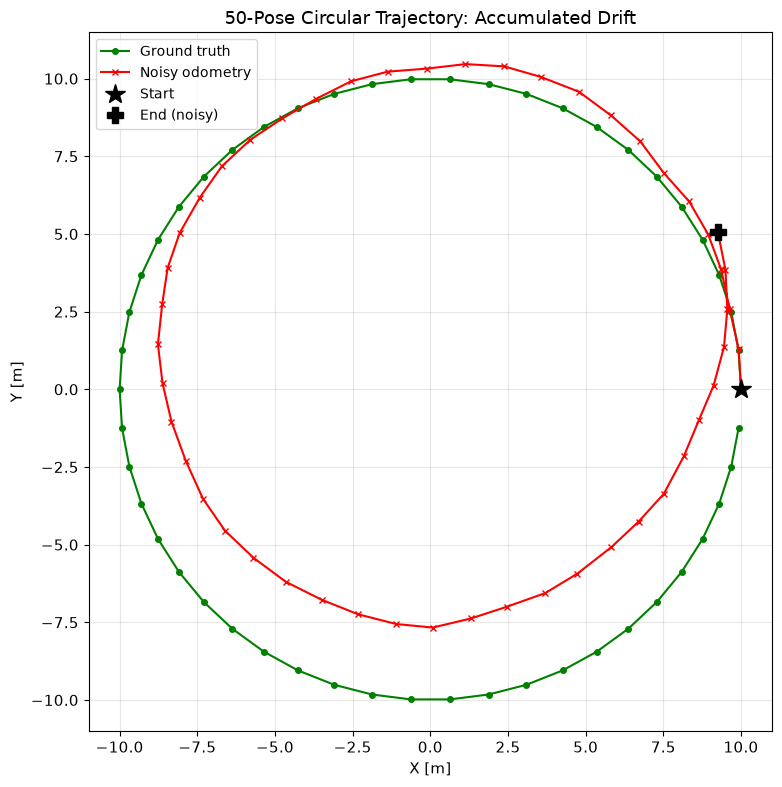

The robot has gone around the circle, but the last pose
is 5.12 m away from the first — this is the accumulated drift.


In [3]:
# ── Generate a synthetic 50-pose circular trajectory ──

np.random.seed(42)

N_POSES = 50
radius = 10.0

angles = np.linspace(0, 2 * np.pi, N_POSES, endpoint=False)
gt_xy = np.column_stack([radius * np.cos(angles), radius * np.sin(angles)])

gt_poses = []
for i in range(N_POSES):
    heading = angles[i] + np.pi / 2
    R = Rotation.from_euler("z", heading).as_matrix()
    gt_poses.append(make_pose(R, np.array([gt_xy[i, 0], gt_xy[i, 1], 0.0])))

# Build odometry edges with noise — drift accumulates!
TRANS_NOISE = 0.06
ROT_NOISE = 0.025

odom_edges = []
noisy_poses = [gt_poses[0].copy()]

for i in range(N_POSES - 1):
    T_rel_gt = se3_compose(se3_inverse(gt_poses[i]), gt_poses[i + 1])
    noise = np.concatenate(
        [np.random.randn(3) * TRANS_NOISE, np.random.randn(3) * ROT_NOISE]
    )
    T_rel_noisy = se3_compose(T_rel_gt, se3_exp(noise))
    odom_edges.append((i, i + 1, T_rel_noisy, np.eye(6) * 100))
    noisy_poses.append(se3_compose(noisy_poses[-1], T_rel_noisy))

noisy_xy = np.array([T[:2, 3] for T in noisy_poses])

fig, ax = plt.subplots(figsize=(8, 8))
ax.plot(gt_xy[:, 0], gt_xy[:, 1], "g-o", ms=4, label="Ground truth")
ax.plot(noisy_xy[:, 0], noisy_xy[:, 1], "r-x", ms=4, label="Noisy odometry")
ax.plot(gt_xy[0, 0], gt_xy[0, 1], "k*", ms=15, label="Start", zorder=5)
ax.plot(noisy_xy[-1, 0], noisy_xy[-1, 1], "kP", ms=12, label="End (noisy)", zorder=5)
ax.set_xlabel("X [m]", fontsize=11)
ax.set_ylabel("Y [m]", fontsize=11)
ax.set_title("50-Pose Circular Trajectory: Accumulated Drift", fontsize=13)
ax.legend(fontsize=10)
ax.set_aspect("equal")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

drift = norm(gt_xy[0] - noisy_xy[-1])
print("The robot has gone around the circle, but the last pose")
print(f"is {drift:.2f} m away from the first — this is the accumulated drift.")

Optimising pose graph (odometry edges only, no loop closure)...


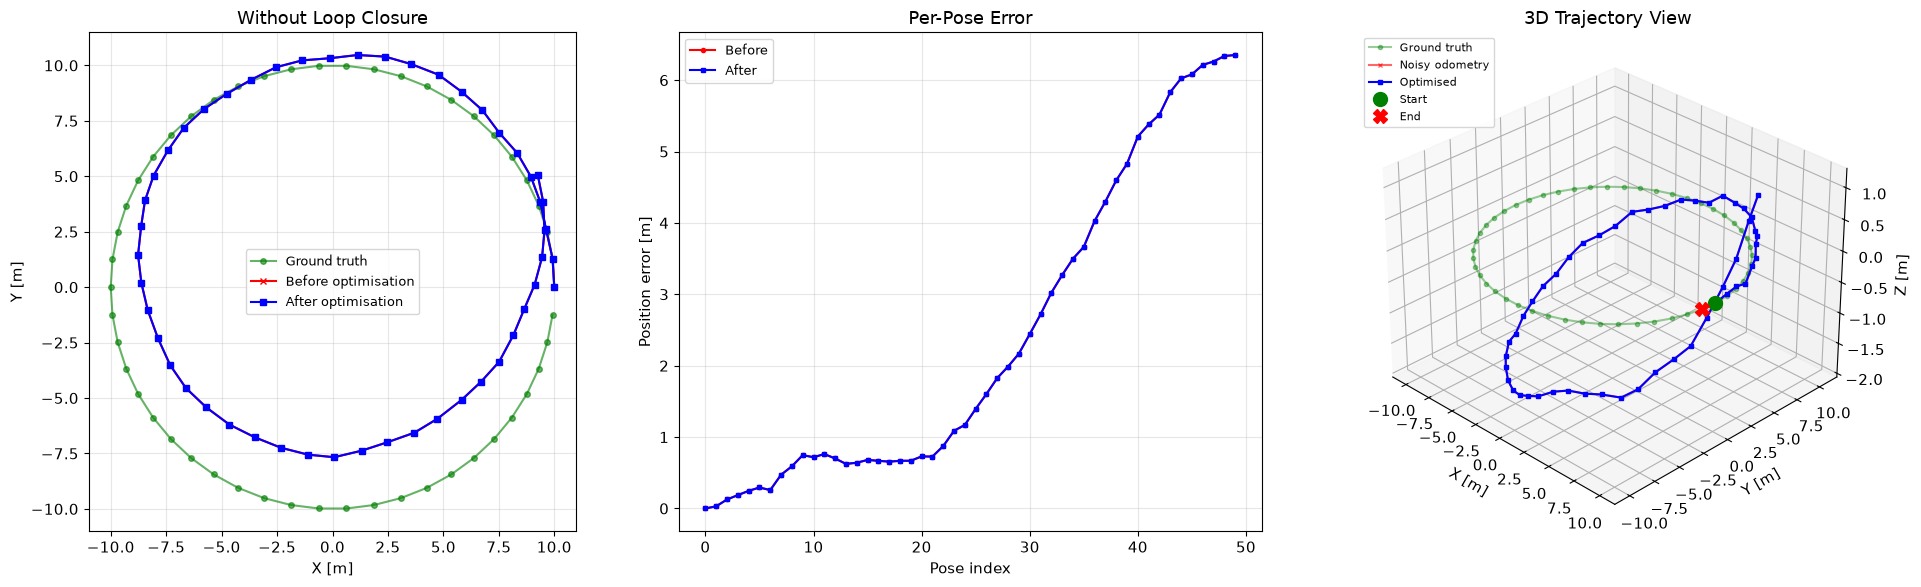

Mean position error before: 2.3778 m
Mean position error after:  2.3778 m
Without loop closure, systematic drift cannot be corrected!


In [4]:
# ── Pose graph optimisation using src.slam.PoseGraph ──

pg = PoseGraph()
for T in noisy_poses:
    pg.add_node(T)
for i, j, T_meas, info in odom_edges:
    pg.add_edge(i, j, T_meas, info)

print("Optimising pose graph (odometry edges only, no loop closure)...")
opt_poses_no_loop = pg.optimize(n_iterations=20, fixed_nodes=[0])

opt_xy_no_loop = np.array([T[:2, 3] for T in opt_poses_no_loop])

fig = plt.figure(figsize=(20, 6))

ax0 = fig.add_subplot(1, 3, 1)
ax0.plot(gt_xy[:, 0], gt_xy[:, 1], "g-o", ms=4, label="Ground truth", alpha=0.6)
ax0.plot(noisy_xy[:, 0], noisy_xy[:, 1], "r-x", ms=4, label="Before optimisation")
ax0.plot(
    opt_xy_no_loop[:, 0], opt_xy_no_loop[:, 1], "b-s", ms=4, label="After optimisation"
)
ax0.set_xlabel("X [m]")
ax0.set_ylabel("Y [m]")
ax0.set_title("Without Loop Closure")
ax0.legend(fontsize=9)
ax0.set_aspect("equal")
ax0.grid(True, alpha=0.3)

errors_before = [norm(gt_xy[i] - noisy_xy[i]) for i in range(N_POSES)]
errors_after = [norm(gt_xy[i] - opt_xy_no_loop[i]) for i in range(N_POSES)]
ax1 = fig.add_subplot(1, 3, 2)
ax1.plot(errors_before, "r-o", ms=3, label="Before")
ax1.plot(errors_after, "b-s", ms=3, label="After")
ax1.set_xlabel("Pose index")
ax1.set_ylabel("Position error [m]")
ax1.set_title("Per-Pose Error")
ax1.legend(fontsize=9)
ax1.grid(True, alpha=0.3)

gt_xyz = np.array([T[:3, 3] for T in gt_poses])
noisy_xyz = np.array([T[:3, 3] for T in noisy_poses])
opt_xyz_no_loop = np.array([T[:3, 3] for T in opt_poses_no_loop])

ax3d = fig.add_subplot(1, 3, 3, projection="3d")
ax3d.plot(
    gt_xyz[:, 0],
    gt_xyz[:, 1],
    gt_xyz[:, 2],
    "g-o",
    ms=3,
    label="Ground truth",
    alpha=0.4,
)
ax3d.plot(
    noisy_xyz[:, 0],
    noisy_xyz[:, 1],
    noisy_xyz[:, 2],
    "r-x",
    ms=3,
    label="Noisy odometry",
    alpha=0.6,
)
ax3d.plot(
    opt_xyz_no_loop[:, 0],
    opt_xyz_no_loop[:, 1],
    opt_xyz_no_loop[:, 2],
    "b-s",
    ms=3,
    label="Optimised",
)
ax3d.plot(*gt_xyz[0], "go", ms=10, zorder=5, label="Start")
ax3d.plot(*gt_xyz[-1], "rX", ms=10, zorder=5, label="End")
ax3d.set_xlabel("X [m]")
ax3d.set_ylabel("Y [m]")
ax3d.set_zlabel("Z [m]")
ax3d.set_title("3D Trajectory View")
ax3d.view_init(elev=30, azim=-45)
ax3d.legend(fontsize=8, loc="upper left")

plt.tight_layout()
plt.show()

print(f"Mean position error before: {np.mean(errors_before):.4f} m")
print(f"Mean position error after:  {np.mean(errors_after):.4f} m")
print("Without loop closure, systematic drift cannot be corrected!")

---
## 3. Loop Closure

### The Drift Problem

Visual odometry accumulates drift over time. After travelling a long circular path, the
estimated trajectory diverges significantly from the ground truth. **Loop closure** —
detecting when the robot revisits a previously seen place — provides a long-range
constraint that corrects this drift.

### DBoW2: Bag of Visual Words

The classic approach to loop-closure detection:

1. **Vocabulary construction**: Cluster a large set of local descriptors (e.g., ORB) using
   hierarchical k-means to build a visual vocabulary tree with \(K\) words.
2. **Image representation**: Each image is converted to a sparse bag-of-words vector
   \(\mathbf{v} \in \mathbb{R}^K\) by assigning each feature to the closest visual word.
3. **TF-IDF weighting**: Weight each word by term frequency–inverse document frequency:
   $$w_k = \frac{n_{ik}}{n_i} \cdot \log\frac{N}{N_k}$$
   where \(n_{ik}\) = occurrences of word \(k\) in image \(i\), \(n_i\) = total words in image \(i\),
   \(N\) = total images, \(N_k\) = images containing word \(k\).
4. **Similarity scoring**: Compare using the \(L_1\)-normalised score:
   $$s(\mathbf{v}_i, \mathbf{v}_j) = 1 - \frac{1}{2} \|\mathbf{v}_i - \mathbf{v}_j\|_1$$
5. **Temporal consistency**: Require matches across multiple consecutive frames.
6. **Geometric verification**: RANSAC + fundamental/essential matrix estimation to
   reject false positives.

### Modern Visual Place Recognition

| Method | Approach | Key Idea |
|--------|----------|----------|
| **NetVLAD** (Arandjelovic 2016) | CNN + VLAD aggregation | End-to-end learned place descriptors |
| **AnyLoc** (Keetha 2023) | Foundation model features | DINOv2 features + VLAD, works across domains |
| **CosPlace** (Berton 2022) | Contrastive learning | Group-based training, efficient retrieval |
| **MixVPR** (Ali-bey 2023) | MLP-Mixer on features | Lightweight, competitive accuracy |
| **EigenPlaces** (Berton 2023) | PCA-informed training | Better descriptor diversity |

Added loop closure edge: pose 0 <-> pose 49
Optimising with loop closure...


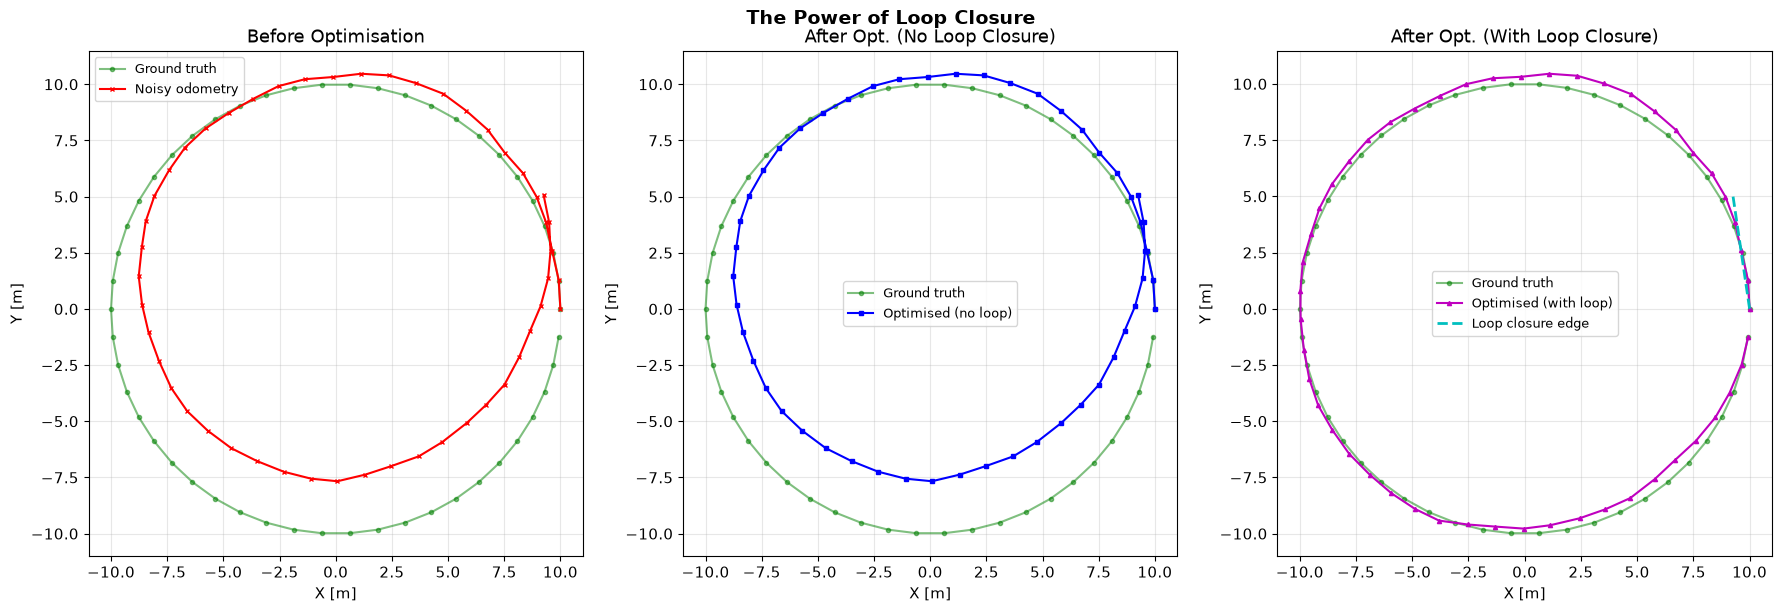

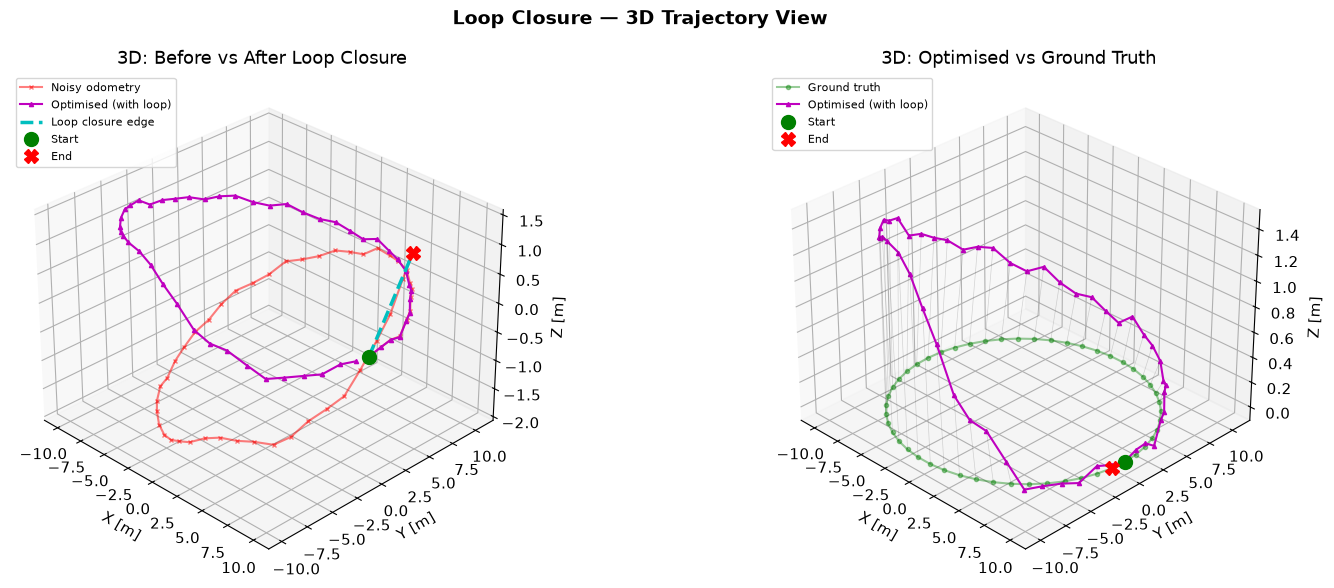

Mean position error:
  Before optimisation:     2.3778 m
  After opt (no loop):     2.3778 m
  After opt (with loop):   0.5611 m
  Improvement from loop:   76.4%


In [5]:
# ── Loop Closure: connect the last pose back to the first ──

LOOP_I, LOOP_J = 0, N_POSES - 1

T_loop_gt = se3_compose(se3_inverse(gt_poses[LOOP_I]), gt_poses[LOOP_J])
loop_noise = np.concatenate([np.random.randn(3) * 0.03, np.random.randn(3) * 0.01])
T_loop_meas = se3_compose(T_loop_gt, se3_exp(loop_noise))
loop_info = np.eye(6) * 200

all_edges_loop = [*odom_edges, (LOOP_I, LOOP_J, T_loop_meas, loop_info)]

pg_loop = PoseGraph()
for T in noisy_poses:
    pg_loop.add_node(T)
for i, j, T_meas, info in all_edges_loop:
    pg_loop.add_edge(i, j, T_meas, info)

print(f"Added loop closure edge: pose {LOOP_I} <-> pose {LOOP_J}")
print("Optimising with loop closure...")
opt_poses_loop = pg_loop.optimize(n_iterations=30, fixed_nodes=[0])

opt_xy_loop = np.array([T[:2, 3] for T in opt_poses_loop])

# ── Visualise: three-panel 2D comparison ──
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for ax in axes:
    ax.plot(gt_xy[:, 0], gt_xy[:, 1], "g-o", ms=3, label="Ground truth", alpha=0.5)

axes[0].plot(noisy_xy[:, 0], noisy_xy[:, 1], "r-x", ms=3, label="Noisy odometry")
axes[0].set_title("Before Optimisation")

axes[1].plot(
    opt_xy_no_loop[:, 0], opt_xy_no_loop[:, 1], "b-s", ms=3, label="Optimised (no loop)"
)
axes[1].set_title("After Opt. (No Loop Closure)")

axes[2].plot(
    opt_xy_loop[:, 0], opt_xy_loop[:, 1], "m-^", ms=3, label="Optimised (with loop)"
)
axes[2].plot(
    [noisy_xy[LOOP_I, 0], noisy_xy[LOOP_J, 0]],
    [noisy_xy[LOOP_I, 1], noisy_xy[LOOP_J, 1]],
    "c--",
    lw=2,
    label="Loop closure edge",
)
axes[2].set_title("After Opt. (With Loop Closure)")

for ax in axes:
    ax.set_xlabel("X [m]")
    ax.set_ylabel("Y [m]")
    ax.legend(fontsize=9)
    ax.set_aspect("equal")
    ax.grid(True, alpha=0.3)

plt.suptitle("The Power of Loop Closure", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

# ── 3D view: loop closure connections ──
opt_xyz_loop = np.array([T[:3, 3] for T in opt_poses_loop])

fig_3d = plt.figure(figsize=(16, 6))

ax3d_a = fig_3d.add_subplot(1, 2, 1, projection="3d")
ax3d_a.plot(
    noisy_xyz[:, 0],
    noisy_xyz[:, 1],
    noisy_xyz[:, 2],
    "r-x",
    ms=3,
    label="Noisy odometry",
    alpha=0.5,
)
ax3d_a.plot(
    opt_xyz_loop[:, 0],
    opt_xyz_loop[:, 1],
    opt_xyz_loop[:, 2],
    "m-^",
    ms=3,
    label="Optimised (with loop)",
)
ax3d_a.plot(
    [noisy_xyz[LOOP_I, 0], noisy_xyz[LOOP_J, 0]],
    [noisy_xyz[LOOP_I, 1], noisy_xyz[LOOP_J, 1]],
    [noisy_xyz[LOOP_I, 2], noisy_xyz[LOOP_J, 2]],
    "c--",
    lw=2.5,
    label="Loop closure edge",
)
ax3d_a.plot(*noisy_xyz[0], "go", ms=10, zorder=5, label="Start")
ax3d_a.plot(*noisy_xyz[-1], "rX", ms=10, zorder=5, label="End")
ax3d_a.set_xlabel("X [m]")
ax3d_a.set_ylabel("Y [m]")
ax3d_a.set_zlabel("Z [m]")
ax3d_a.set_title("3D: Before vs After Loop Closure")
ax3d_a.view_init(elev=30, azim=-45)
ax3d_a.legend(fontsize=8, loc="upper left")

ax3d_b = fig_3d.add_subplot(1, 2, 2, projection="3d")
ax3d_b.plot(
    gt_xyz[:, 0],
    gt_xyz[:, 1],
    gt_xyz[:, 2],
    "g-o",
    ms=3,
    label="Ground truth",
    alpha=0.4,
)
ax3d_b.plot(
    opt_xyz_loop[:, 0],
    opt_xyz_loop[:, 1],
    opt_xyz_loop[:, 2],
    "m-^",
    ms=3,
    label="Optimised (with loop)",
)
for k in range(N_POSES):
    ax3d_b.plot(
        [gt_xyz[k, 0], opt_xyz_loop[k, 0]],
        [gt_xyz[k, 1], opt_xyz_loop[k, 1]],
        [gt_xyz[k, 2], opt_xyz_loop[k, 2]],
        "k-",
        alpha=0.15,
        lw=0.5,
    )
ax3d_b.plot(*gt_xyz[0], "go", ms=10, zorder=5, label="Start")
ax3d_b.plot(*gt_xyz[-1], "rX", ms=10, zorder=5, label="End")
ax3d_b.set_xlabel("X [m]")
ax3d_b.set_ylabel("Y [m]")
ax3d_b.set_zlabel("Z [m]")
ax3d_b.set_title("3D: Optimised vs Ground Truth")
ax3d_b.view_init(elev=30, azim=-45)
ax3d_b.legend(fontsize=8, loc="upper left")

plt.suptitle("Loop Closure — 3D Trajectory View", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

err_before = np.mean([norm(gt_xy[i] - noisy_xy[i]) for i in range(N_POSES)])
err_no_loop = np.mean([norm(gt_xy[i] - opt_xy_no_loop[i]) for i in range(N_POSES)])
err_loop = np.mean([norm(gt_xy[i] - opt_xy_loop[i]) for i in range(N_POSES)])

print("Mean position error:")
print(f"  Before optimisation:     {err_before:.4f} m")
print(f"  After opt (no loop):     {err_no_loop:.4f} m")
print(f"  After opt (with loop):   {err_loop:.4f} m")
print(f"  Improvement from loop:   {(1 - err_loop / err_before) * 100:.1f}%")

---
## 4. Bundle Adjustment

### Joint Optimisation of Cameras and 3D Points

While pose graph optimisation marginalises out the map and optimises only poses,
**bundle adjustment** (BA) jointly optimises camera poses \(\{T_i\}\) and 3D landmark
positions \(\{\ell_j\}\) by minimising reprojection error:

$$
\min_{\{T_i\}, \{\ell_j\}} \sum_{(i,j) \in \mathcal{O}} \left\| z_{ij} - \pi(T_i, \ell_j) \right\|_{\Sigma_{ij}}^2
$$

where \(\pi(T_i, \ell_j) = K \cdot \operatorname{dehom}\!\bigl(T_i^{-1} \bar{\ell}_j\bigr)\) is the
projection and \(K = \begin{pmatrix} f_x & 0 & c_x \\ 0 & f_y & c_y \\ 0 & 0 & 1 \end{pmatrix}\).

### The Hessian Structure

Stack the unknowns as \(\mathbf{x} = (\underbrace{\xi_1, \ldots, \xi_M}_{\text{cameras}}, \underbrace{\ell_1, \ldots, \ell_N}_{\text{points}})\).

The Gauss–Newton Hessian has a characteristic **arrow** structure:

$$
H = \begin{bmatrix} H_{cc} & H_{cp} \\ H_{pc} & H_{pp} \end{bmatrix}
$$

where:
- \(H_{cc} \in \mathbb{R}^{6M \times 6M}\): camera–camera block (block diagonal if no pose–pose constraints)
- \(H_{pp} \in \mathbb{R}^{3N \times 3N}\): point–point block (**block diagonal** — each point is independent!)
- \(H_{cp} = H_{pc}^\top\): camera–point cross terms (sparse)

### The Schur Complement Trick — Derivation

The full system \(H \, \delta\mathbf{x} = -\mathbf{b}\) can be written:

$$
\begin{bmatrix} H_{cc} & H_{cp} \\ H_{pc} & H_{pp} \end{bmatrix}
\begin{bmatrix} \delta\boldsymbol{\xi} \\ \delta\boldsymbol{\ell} \end{bmatrix}
= -\begin{bmatrix} \mathbf{b}_c \\ \mathbf{b}_p \end{bmatrix}
$$

**Step 1.** From the second block row:

$$
H_{pc} \, \delta\boldsymbol{\xi} + H_{pp} \, \delta\boldsymbol{\ell} = -\mathbf{b}_p
$$

$$
\Rightarrow \quad \delta\boldsymbol{\ell} = H_{pp}^{-1}\bigl(-\mathbf{b}_p - H_{pc} \, \delta\boldsymbol{\xi}\bigr)
$$

Since \(H_{pp}\) is **block diagonal** (each \(3 \times 3\) block corresponds to one point),
\(H_{pp}^{-1}\) is computed by inverting each \(3 \times 3\) block independently — cost \(O(N)\).

**Step 2.** Substitute into the first block row:

$$
H_{cc} \, \delta\boldsymbol{\xi} + H_{cp} \, H_{pp}^{-1}\bigl(-\mathbf{b}_p - H_{pc} \, \delta\boldsymbol{\xi}\bigr) = -\mathbf{b}_c
$$

$$
\bigl(H_{cc} - H_{cp} \, H_{pp}^{-1} \, H_{pc}\bigr) \, \delta\boldsymbol{\xi} = -\mathbf{b}_c + H_{cp} \, H_{pp}^{-1} \, \mathbf{b}_p
$$

This gives the **reduced camera system** (Schur complement):

$$
\boxed{S \, \delta\boldsymbol{\xi} = -\mathbf{b}_c^*}
$$

$$
\boxed{S = H_{cc} - H_{cp} \, H_{pp}^{-1} \, H_{pc} \in \mathbb{R}^{6M \times 6M}}
$$

$$
\boxed{\mathbf{b}_c^* = \mathbf{b}_c - H_{cp} \, H_{pp}^{-1} \, \mathbf{b}_p}
$$

**Step 3.** Back-substitute for point updates:

$$
\delta\boldsymbol{\ell} = H_{pp}^{-1}\bigl(-\mathbf{b}_p - H_{pc} \, \delta\boldsymbol{\xi}\bigr)
$$

### Why This Is Efficient

| | Full System | Schur Complement |
|---|---|---|
| **Size** | \((6M + 3N) \times (6M + 3N)\) | \(6M \times 6M\) |
| **Complexity** | \(O((6M + 3N)^3)\) | \(O((6M)^3 + N)\) |

Typically \(N \gg M\) (thousands of points, tens of cameras), so the Schur complement
reduces the solve from intractable to efficient.

### Reprojection Jacobians — Step-by-Step Derivation

**Goal:** Derive the Jacobians of the reprojection error
\(e_{ij} = z_{ij} - \pi(T_i, \ell_j)\) with respect to camera pose \(\xi_i\) and point \(\ell_j\).

**Step 1 — Projection function.** The projection pipeline is:

$$
\ell_j \xrightarrow{\text{transform}} \mathbf{p} = R_i^{-1}(\ell_j - t_i)
\xrightarrow{\text{normalise}} \bar{\mathbf{p}} = (p_x/p_z,\; p_y/p_z)
\xrightarrow{K} \mathbf{u} = (f_x \bar{p}_x + c_x,\; f_y \bar{p}_y + c_y)
$$

**Step 2 — Projection Jacobian \(J_\pi\).** Differentiating \(\mathbf{u}\) with respect to \(\mathbf{p}\):

$$
\frac{\partial u_x}{\partial p_x} = \frac{f_x}{p_z}, \quad
\frac{\partial u_x}{\partial p_z} = -\frac{f_x \, p_x}{p_z^2}
$$

by the quotient rule on \(p_x / p_z\). Collecting all terms:

$$
J_\pi = \frac{\partial \mathbf{u}}{\partial \mathbf{p}} =
\frac{1}{p_z} \begin{bmatrix} f_x & 0 & -f_x\,p_x/p_z \\ 0 & f_y & -f_y\,p_y/p_z \end{bmatrix}
\in \mathbb{R}^{2 \times 3}
$$

**Step 3 — Point Jacobian.** Since \(\mathbf{p} = R_i^{-1}(\ell_j - t_i)\), the derivative
with respect to \(\ell_j\) is simply \(\partial \mathbf{p} / \partial \ell_j = R_i^{-1}\), so by the chain rule:

$$
\frac{\partial e_{ij}}{\partial \ell_j} = -J_\pi \, R_i^{-1} \in \mathbb{R}^{2 \times 3}
$$

**Step 4 — Camera Jacobian (Lie algebra perturbation).** We perturb the camera-to-world
pose \(T_i\) by a right perturbation \(T_i \leftarrow T_i \cdot \exp(\hat{\delta\xi})\), where
\(\delta\xi = (\delta\rho, \delta\phi) \in \mathbb{R}^6\) (translation, rotation).

The point in camera frame becomes \(\mathbf{p}' = \exp(-\hat{\delta\xi}) \mathbf{p}\).
Linearising \(\exp(-\hat{\delta\xi}) \approx I - \hat{\delta\xi}\):

$$
\mathbf{p}' \approx \mathbf{p} - \delta\rho - \delta\phi \times \mathbf{p}
= \mathbf{p} - \delta\rho + [\mathbf{p}]_\times \delta\phi
$$

Therefore \(\partial \mathbf{p} / \partial \delta\xi = \begin{bmatrix} -I_3 & [\mathbf{p}]_\times \end{bmatrix} \in \mathbb{R}^{3 \times 6}\), and:

$$
\frac{\partial e_{ij}}{\partial \delta\xi_i} = -J_\pi \begin{bmatrix} -I_3 & [\mathbf{p}]_\times \end{bmatrix} \in \mathbb{R}^{2 \times 6}
$$

The first 3 columns (translation) are \(J_\pi\) (a nearby point shifts its projection).
The last 3 columns (rotation) involve \(J_\pi [\mathbf{p}]_\times\) — rotating the camera
moves the point tangentially, and the cross product encodes this.

Generated 114 observations from 8 cameras, 40 points.
Running bundle adjustment (Schur complement)...


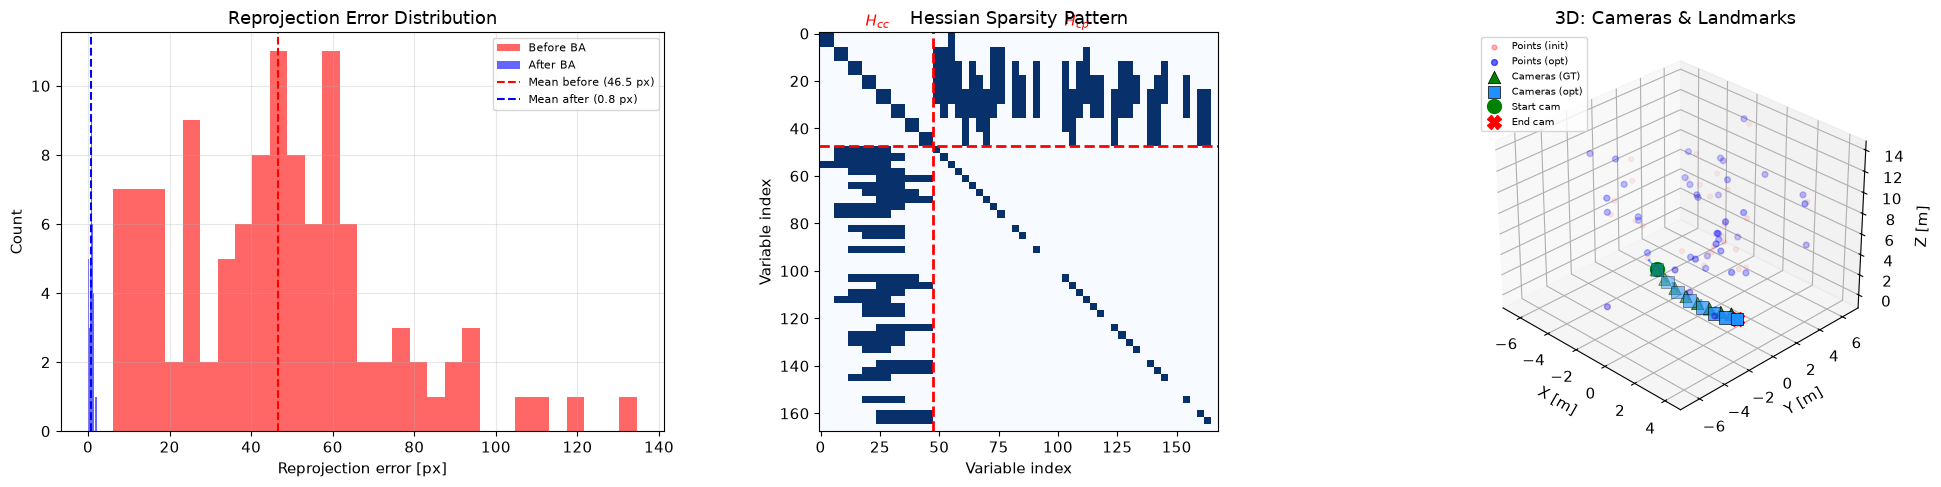

Mean reproj error: before = 46.47 px, after = 0.79 px
H_pp is block-diagonal => cheap Schur complement.


In [6]:
# ── Bundle Adjustment demonstration using src.slam.BundleAdjuster ──

np.random.seed(123)

N_CAMS = 8
N_PTS = 40
fx, fy, cx, cy = 500, 500, 320, 240
K_intr = np.array([[fx, 0, cx], [0, fy, cy], [0, 0, 1.0]])

pts_gt = np.random.randn(N_PTS, 3) * 2.5 + np.array([0, 0, 8])

cam_poses_gt = []
for i in range(N_CAMS):
    angle = (i - N_CAMS // 2) * 0.2
    R = Rotation.from_euler("y", angle).as_matrix()
    t = np.array([np.sin(angle) * 4, 0, -np.cos(angle) * 4 + 4])
    cam_poses_gt.append(make_pose(R, t))


def project(T_cw, pt, K):
    R, t = se3_to_Rt(se3_inverse(T_cw))
    p = R @ pt + t
    if p[2] <= 0.1:
        return None
    uv = K @ p
    return uv[:2] / uv[2]


OBS_NOISE = 1.0
observations = []
for ci, T in enumerate(cam_poses_gt):
    for pj, pt in enumerate(pts_gt):
        uv = project(T, pt, K_intr)
        if uv is not None and 0 <= uv[0] < 640 and 0 <= uv[1] < 480:
            observations.append((ci, pj, uv + np.random.randn(2) * OBS_NOISE))

print(
    f"Generated {len(observations)} observations from {N_CAMS} cameras, {N_PTS} points."
)

# Add noise to initial estimates
cam_poses_init = [T @ se3_exp(np.random.randn(6) * 0.05) for T in cam_poses_gt]
pts_init = [pt + np.random.randn(3) * 0.3 for pt in pts_gt]

ba = BundleAdjuster()
for _ci, T in enumerate(cam_poses_init):
    ba.add_camera(T, K_intr)
for _pj, pt in enumerate(pts_init):
    ba.add_point(pt)
for ci, pj, uv in observations:
    ba.add_observation(ci, pj, uv)

print("Running bundle adjustment (Schur complement)...")
opt_cams, opt_pts = ba.optimize(n_iterations=15, fix_cameras=[0], damping=1e-4)


def reproj_error(cams, pts, obs, K):
    errs = []
    for ci, pj, uv_obs in obs:
        uv_pred = project(cams[ci], pts[pj], K)
        if uv_pred is not None:
            errs.append(norm(uv_pred - uv_obs))
    return np.array(errs)


err_init = reproj_error(cam_poses_init, pts_init, observations, K_intr)
err_opt = reproj_error(opt_cams, opt_pts, observations, K_intr)

fig = plt.figure(figsize=(20, 5))

ax_hist = fig.add_subplot(1, 3, 1)
ax_hist.hist(err_init, bins=30, alpha=0.6, color="red", label="Before BA")
ax_hist.hist(err_opt, bins=30, alpha=0.6, color="blue", label="After BA")
ax_hist.axvline(
    err_init.mean(),
    color="red",
    ls="--",
    lw=1.5,
    label=f"Mean before ({err_init.mean():.1f} px)",
)
ax_hist.axvline(
    err_opt.mean(),
    color="blue",
    ls="--",
    lw=1.5,
    label=f"Mean after ({err_opt.mean():.1f} px)",
)
ax_hist.set_xlabel("Reprojection error [px]")
ax_hist.set_ylabel("Count")
ax_hist.set_title("Reprojection Error Distribution")
ax_hist.legend(fontsize=8)
ax_hist.grid(True, alpha=0.3)

cam_dim = 6 * N_CAMS
pt_dim = 3 * N_PTS
total = cam_dim + pt_dim
H_spy = np.zeros((total, total))
for ci, pj, _ in observations:
    cb = ci * 6
    pb = cam_dim + pj * 3
    H_spy[cb : cb + 6, cb : cb + 6] = 1
    H_spy[pb : pb + 3, pb : pb + 3] = 1
    H_spy[cb : cb + 6, pb : pb + 3] = 1
    H_spy[pb : pb + 3, cb : cb + 6] = 1

ax_spy = fig.add_subplot(1, 3, 2)
ax_spy.imshow(H_spy > 0, cmap="Blues", interpolation="nearest")
ax_spy.axhline(cam_dim - 0.5, color="red", lw=2, ls="--")
ax_spy.axvline(cam_dim - 0.5, color="red", lw=2, ls="--")
ax_spy.set_xlabel("Variable index")
ax_spy.set_ylabel("Variable index")
ax_spy.set_title("Hessian Sparsity Pattern")
ax_spy.text(cam_dim / 2, -3, "$H_{cc}$", ha="center", fontsize=11, color="red")
ax_spy.text(cam_dim + pt_dim / 2, -3, "$H_{cp}$", ha="center", fontsize=11, color="red")

pts_opt_arr = np.array(opt_pts)
pts_init_arr = np.array(pts_init)
cam_pos_init = np.array([T[:3, 3] for T in cam_poses_init])
cam_pos_opt = np.array([T[:3, 3] for T in opt_cams])
cam_pos_gt = np.array([T[:3, 3] for T in cam_poses_gt])

ax_ba3d = fig.add_subplot(1, 3, 3, projection="3d")
ax_ba3d.scatter(*pts_init_arr.T, c="red", s=12, alpha=0.3, label="Points (init)")
ax_ba3d.scatter(*pts_opt_arr.T, c="blue", s=18, alpha=0.6, label="Points (opt)")
ax_ba3d.scatter(
    *cam_pos_gt.T,
    c="green",
    s=80,
    marker="^",
    edgecolors="k",
    linewidths=0.5,
    label="Cameras (GT)",
    zorder=5,
)
ax_ba3d.scatter(
    *cam_pos_opt.T,
    c="dodgerblue",
    s=80,
    marker="s",
    edgecolors="k",
    linewidths=0.5,
    label="Cameras (opt)",
    zorder=5,
)
for k in range(N_CAMS):
    R_opt, t_opt = se3_to_Rt(opt_cams[k])
    direction = R_opt[:, 2] * 0.8
    ax_ba3d.quiver(
        cam_pos_opt[k, 0],
        cam_pos_opt[k, 1],
        cam_pos_opt[k, 2],
        direction[0],
        direction[1],
        direction[2],
        color="dodgerblue",
        alpha=0.5,
        arrow_length_ratio=0.15,
    )
ax_ba3d.plot(*cam_pos_opt[0], "go", ms=10, zorder=6, label="Start cam")
ax_ba3d.plot(*cam_pos_opt[-1], "rX", ms=10, zorder=6, label="End cam")
ax_ba3d.set_xlabel("X [m]")
ax_ba3d.set_ylabel("Y [m]")
ax_ba3d.set_zlabel("Z [m]")
ax_ba3d.set_title("3D: Cameras & Landmarks")
ax_ba3d.view_init(elev=30, azim=-45)
ax_ba3d.legend(fontsize=7, loc="upper left")

plt.tight_layout()
plt.show()

print(
    f"Mean reproj error: before = {err_init.mean():.2f} px, after = {err_opt.mean():.2f} px"
)
print("H_pp is block-diagonal => cheap Schur complement.")

---
## 5. Robust Estimation

In real SLAM, outliers are inevitable: wrong feature matches, perceptual aliasing in
loop closures, dynamic objects. Standard least squares is highly sensitive to outliers —
a single wrong loop closure can destroy the entire map.

### The Problem with Least Squares

The standard cost \(\rho(s) = \frac{1}{2}s^2\) grows quadratically. A single outlier with
residual 10x larger than inliers contributes 100x more to the cost, dominating the
optimisation and pulling the solution toward the outlier.

### M-Estimators

Replace the squared cost with a **robust kernel** \(\rho(s)\) that grows sub-quadratically:

**Huber kernel** — convex, transitions from \(L_2\) (quadratic) to \(L_1\) (linear):

$$
\rho_{\text{Huber}}(s) = \begin{cases}
\frac{1}{2}s^2 & |s| \le c \\
c|s| - \frac{1}{2}c^2 & |s| > c
\end{cases}
\qquad
w(s) = \frac{\rho'(s)}{s} = \begin{cases}
1 & |s| \le c \\
c / |s| & |s| > c
\end{cases}
$$

*Derivation of the weight:* \(\rho'(s) = \min(|s|, c) \cdot \text{sign}(s)\), so
\(w(s) = \rho'(s)/s = \min(1, c/|s|)\). This means outliers (\(|s| > c\)) receive weight
\(c/|s| < 1\), reducing their influence.

**Cauchy (Lorentzian) kernel** — non-convex, more aggressive outlier suppression:

$$
\rho_{\text{Cauchy}}(s) = \frac{c^2}{2}\ln\!\left(1 + \frac{s^2}{c^2}\right)
\qquad
w(s) = \frac{1}{1 + s^2/c^2}
$$

*Derivation:* \(\rho'(s) = \frac{s}{1 + s^2/c^2}\). Therefore \(w(s) = \rho'(s)/s = \frac{1}{1 + s^2/c^2}\).
The influence function \(\psi(s) = \rho'(s)\) is **redescending** — extreme outliers
contribute almost zero gradient.

**Geman-McClure kernel** — even more robust, bounded influence:

$$
\rho_{\text{GM}}(s) = \frac{s^2 / 2}{c^2 + s^2}
\qquad
w(s) = \frac{c^2}{(c^2 + s^2)^2}
$$

*Derivation:* Using the quotient rule,
\(\rho'(s) = \frac{s \cdot (c^2 + s^2) - s^2 \cdot 2s}{2(c^2+s^2)^2} \cdot 2 = \frac{c^2 s}{(c^2+s^2)^2}\).
Hence \(w(s) = \rho'(s)/s = \frac{c^2}{(c^2+s^2)^2}\).
As \(|s| \to \infty\), \(w \to 0\): outliers are completely ignored.

### Summary Table

| Kernel | \(\rho(s)\) | Weight \(w(s)\) | Convex? | Behaviour |
|--------|-----------|---------------|---------|-----------|
| **L2** | \(\frac{1}{2}s^2\) | \(1\) | Yes | No robustness |
| **Huber** | \(\begin{cases} \frac{1}{2}s^2 \\ c \vert s \vert - \frac{c^2}{2} \end{cases}\) | \(\min(1, c/\vert s \vert)\) | Yes | Linear tails |
| **Cauchy** | \(\frac{c^2}{2}\ln(1+s^2/c^2)\) | \(\frac{1}{1+s^2/c^2}\) | No | Logarithmic tails |
| **Geman-McClure** | \(\frac{s^2/2}{c^2+s^2}\) | \(\frac{c^2}{(c^2+s^2)^2}\) | No | Bounded cost |

### Iteratively Reweighted Least Squares (IRLS)

Minimising \(\sum_k \rho(\|e_k\|)\) is equivalent to solving a sequence of **weighted**
least squares problems:

$$
\boxed{\min \sum_k w_k^{(t)} \|e_k\|^2, \qquad w_k^{(t)} = \frac{\rho'(\|e_k^{(t)}\|)}{\|e_k^{(t)}\|}}
$$

At each IRLS iteration:
1. Compute residuals \(e_k\) with current parameter estimates.
2. Compute weights \(w_k = \rho'(\|e_k\|) / \|e_k\|\) from the chosen kernel.
3. Solve the **weighted** Gauss–Newton system \(H^w \delta x = -b^w\) where
   \(H^w = \sum_k w_k J_k^\top \Omega_k J_k\) and \(b^w = \sum_k w_k J_k^\top \Omega_k e_k\).
4. Update parameters.
5. Repeat until convergence.

### Graduated Non-Convexity (GNC)

Non-convex kernels (Cauchy, GM) create local minima. **GNC** anneals from a convex
surrogate (\(\mu \to \infty\), where \(\rho_\mu \to r^2\), i.e. L2) to the target robust cost (\(\mu = 1\), the original non-convex kernel):

$$
\rho_\mu(s) = \frac{\mu \, c^2 \, s^2}{\mu \, c^2 + s^2}
$$

The algorithm: start with \(\mu \gg 1\) (e.g. \(\mu_0 = 10^2\), making the cost nearly convex), solve, decrease \(\mu \leftarrow \mu / \alpha\), repeat until \(\mu \leq 1\).

**Why robust kernels matter**: In real SLAM systems, loop-closure detections can be **wrong** — the place recognizer may confuse two visually similar but spatially distant locations. A single false loop closure with standard least-squares will corrupt the entire trajectory. Robust kernels (Huber, Cauchy, Geman-McClure) downweight high-residual edges, making the optimizer tolerant to these outliers. The IRLS (Iteratively Reweighted Least Squares) approach below solves a sequence of weighted least-squares problems, where the weights decrease for high-residual edges.

> **2026 frontier — Graduated Non-Convexity (GNC)**: Instead of choosing a fixed robust kernel, GNC (Yang et al., 2020) starts with a convex surrogate and gradually morphs it into the true non-convex cost. This avoids local minima that IRLS can get trapped in. Systems like HiRo-SLAM and riSAM use GNC for certifiably robust SLAM.

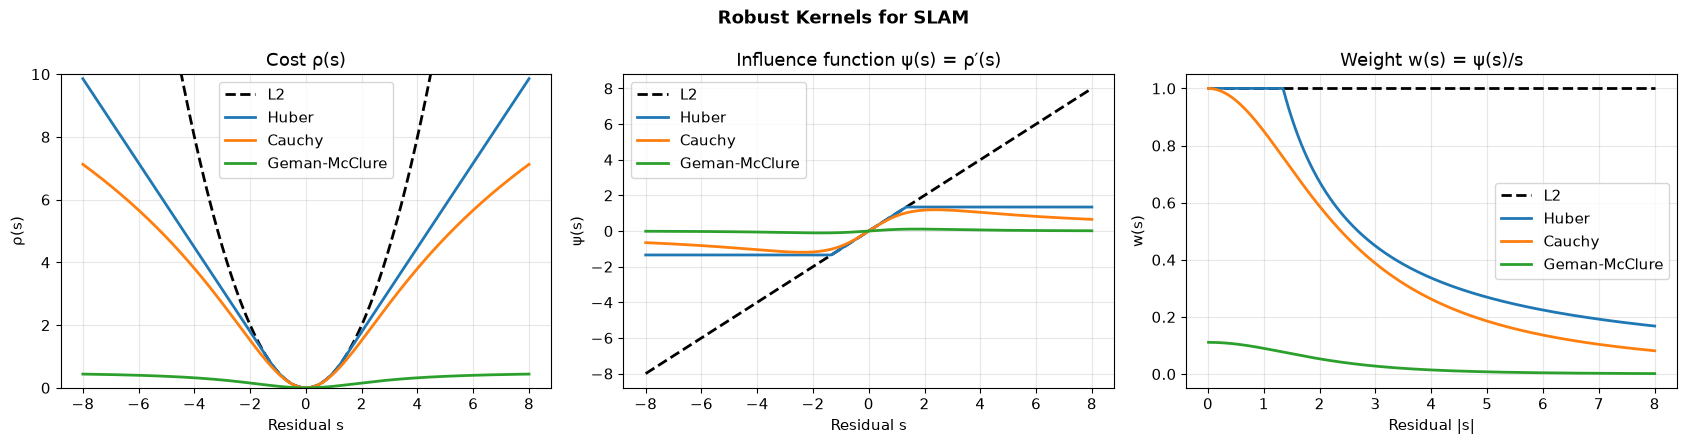

In [7]:
# ── Robust kernels: cost, influence, and weight functions ──


def geman_mcclure_cost(s, c=3.0):
    return 0.5 * s**2 / (c**2 + s**2)


def geman_mcclure_weight(s, c=3.0):
    return c**2 / (c**2 + s**2) ** 2


s_vals = np.linspace(-8, 8, 500)
s_pos = np.linspace(0.01, 8, 300)

h_cost = np.array([huber_kernel(si, delta=1.345)[0] for si in s_vals])
h_wt = np.array([huber_kernel(si, delta=1.345)[1] for si in s_pos])
c_cost = np.array([cauchy_kernel(si, c=2.385)[0] for si in s_vals])
c_wt = np.array([cauchy_kernel(si, c=2.385)[1] for si in s_pos])

fig, axes = plt.subplots(1, 3, figsize=(17, 4.5))

axes[0].plot(s_vals, 0.5 * s_vals**2, "k--", lw=2, label="L2")
axes[0].plot(s_vals, h_cost, lw=2, label="Huber")
axes[0].plot(s_vals, c_cost, lw=2, label="Cauchy")
axes[0].plot(s_vals, geman_mcclure_cost(s_vals), lw=2, label="Geman-McClure")
axes[0].set_title("Cost ρ(s)")
axes[0].set_ylim(0, 10)
axes[0].set_xlabel("Residual s")
axes[0].set_ylabel("ρ(s)")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(s_vals, s_vals, "k--", lw=2, label="L2")
axes[1].plot(
    s_vals,
    np.array([huber_kernel(si, 1.345)[1] * si for si in s_vals]),
    lw=2,
    label="Huber",
)
axes[1].plot(
    s_vals,
    np.array([cauchy_kernel(si, 2.385)[1] * si for si in s_vals]),
    lw=2,
    label="Cauchy",
)
gm_infl = s_vals * 3.0**2 / (3.0**2 + s_vals**2) ** 2 * (3.0**2 + s_vals**2)
axes[1].plot(
    s_vals, s_vals * geman_mcclure_weight(s_vals, 3.0), lw=2, label="Geman-McClure"
)
axes[1].set_title("Influence function ψ(s) = ρ′(s)")
axes[1].set_xlabel("Residual s")
axes[1].set_ylabel("ψ(s)")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

axes[2].plot(s_pos, np.ones_like(s_pos), "k--", lw=2, label="L2")
axes[2].plot(s_pos, h_wt, lw=2, label="Huber")
axes[2].plot(s_pos, c_wt, lw=2, label="Cauchy")
axes[2].plot(s_pos, geman_mcclure_weight(s_pos), lw=2, label="Geman-McClure")
axes[2].set_title("Weight w(s) = ψ(s)/s")
axes[2].set_xlabel("Residual |s|")
axes[2].set_ylabel("w(s)")
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.suptitle("Robust Kernels for SLAM", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

Edges: 49 odometry + 1 correct loop + 3 outlier loops

--- Standard (non-robust) optimisation ---



--- Robust (Cauchy IRLS) optimisation ---

Final weights for loop closures:
  Correct loop: w = 0.9882
  Outlier (3,30): w = 0.1703
  Outlier (10,40): w = 0.3177
  Outlier (20,45): w = 0.3025


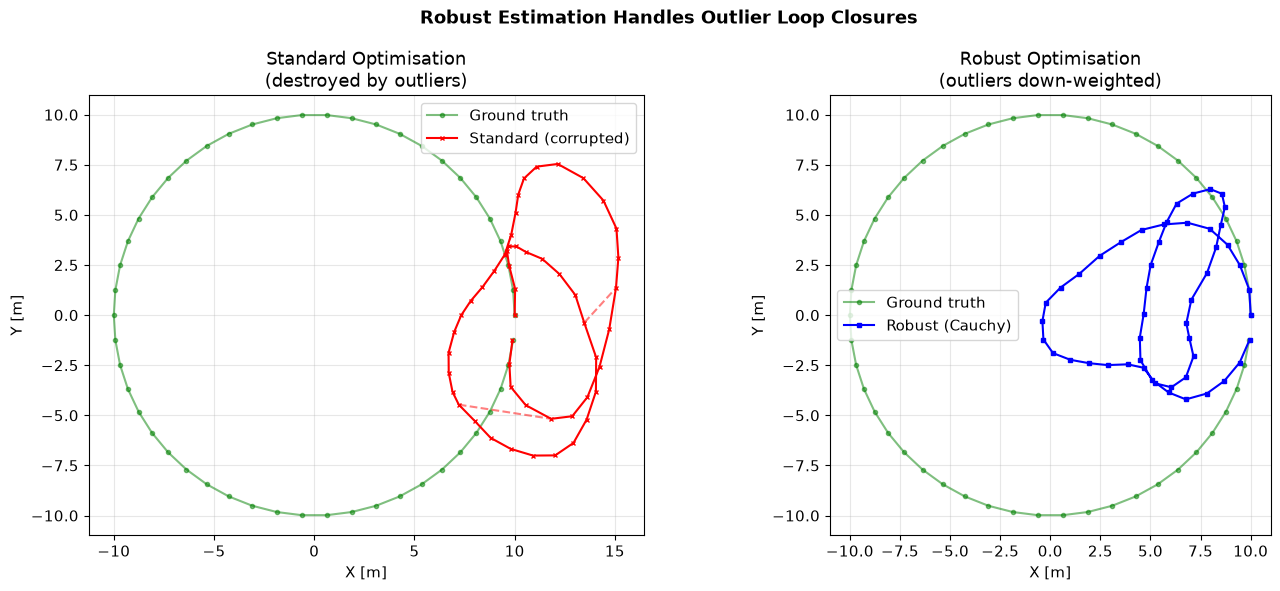


Mean error: Standard = 13.8475 m | Robust = 10.2853 m


In [8]:
# ── Robust pose graph optimisation with IRLS ──


def robust_pose_graph_optimize(
    poses, edges, n_iter=15, irls_iter=5, kernel_fn=None, fix_first=True
):
    N = len(poses)
    dim = 6
    total_dim = N * dim
    poses = [T.copy() for T in poses]

    weights: list[float] = [1.0] * len(edges)

    for _outer in range(irls_iter):
        weights = []
        for i, j, T_meas, _info in edges:
            e = pose_error(poses[i], poses[j], T_meas)
            r = norm(e)
            if kernel_fn is not None and r > 1e-10:
                _, w = kernel_fn(r)
            else:
                w = 1.0
            weights.append(float(w))

        for _it in range(n_iter):
            H = np.zeros((total_dim, total_dim))
            b = np.zeros(total_dim)

            for idx, (i, j, T_meas, info) in enumerate(edges):
                e = pose_error(poses[i], poses[j], T_meas)
                A, B = pose_jacobians(poses[i], poses[j], e)
                W = weights[idx] * info
                si, sj = i * dim, j * dim
                H[si : si + dim, si : si + dim] += A.T @ W @ A
                H[si : si + dim, sj : sj + dim] += A.T @ W @ B
                H[sj : sj + dim, si : si + dim] += B.T @ W @ A
                H[sj : sj + dim, sj : sj + dim] += B.T @ W @ B
                b[si : si + dim] += A.T @ W @ e
                b[sj : sj + dim] += B.T @ W @ e

            if fix_first:
                H[:dim, :] = 0
                H[:, :dim] = 0
                H[:dim, :dim] = np.eye(dim) * 1e6
                b[:dim] = 0

            dx = np.linalg.solve(H + 1e-8 * np.eye(total_dim), -b)
            for k in range(N):
                xi = np.asarray(dx[k * dim : (k + 1) * dim], dtype=np.float64)
                poses[k] = se3_compose(poses[k], se3_exp(xi))
            if norm(dx) < 1e-8:
                break

    return poses, weights


# ── Build edges with outlier loop closures ──
np.random.seed(777)

edges_robust = list(odom_edges)
edges_robust.append((LOOP_I, LOOP_J, T_loop_meas, loop_info))

outlier_pairs = [(3, 30), (10, 40), (20, 45)]
for oi, oj in outlier_pairs:
    T_outlier = se3_exp(np.random.randn(6) * 3.0)
    edges_robust.append((oi, oj, T_outlier, np.eye(6) * 150))

print(
    f"Edges: {len(odom_edges)} odometry + 1 correct loop + "
    f"{len(outlier_pairs)} outlier loops"
)

# Standard PoseGraph (corrupted)
print("\n--- Standard (non-robust) optimisation ---")
pg_std = PoseGraph()
for T in noisy_poses:
    pg_std.add_node(T)
for i, j, T_m, info in edges_robust:
    pg_std.add_edge(i, j, T_m, info)
opt_std = pg_std.optimize(n_iterations=20, fixed_nodes=[0])

# Robust (Cauchy IRLS)
print("\n--- Robust (Cauchy IRLS) optimisation ---")
opt_robust, final_w = robust_pose_graph_optimize(
    list(noisy_poses),
    edges_robust,
    n_iter=5,
    irls_iter=3,
    kernel_fn=lambda r: cauchy_kernel(r, c=1.5),
)

n_odom = len(odom_edges)
print("\nFinal weights for loop closures:")
print(f"  Correct loop: w = {final_w[n_odom]:.4f}")
for k, (oi, oj) in enumerate(outlier_pairs):
    print(f"  Outlier ({oi},{oj}): w = {final_w[n_odom + 1 + k]:.4f}")

# ── Visualise ──
opt_xy_std = np.array([T[:2, 3] for T in opt_std])
opt_xy_rob = np.array([T[:2, 3] for T in opt_robust])

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax in axes:
    ax.plot(gt_xy[:, 0], gt_xy[:, 1], "g-o", ms=3, label="Ground truth", alpha=0.5)

axes[0].plot(
    opt_xy_std[:, 0], opt_xy_std[:, 1], "r-x", ms=3, label="Standard (corrupted)"
)
for oi, oj in outlier_pairs:
    axes[0].plot(
        [opt_xy_std[oi, 0], opt_xy_std[oj, 0]],
        [opt_xy_std[oi, 1], opt_xy_std[oj, 1]],
        "r--",
        alpha=0.5,
    )
axes[0].set_xlabel("X [m]")
axes[0].set_ylabel("Y [m]")
axes[0].set_title("Standard Optimisation\n(destroyed by outliers)")
axes[0].legend()
axes[0].set_aspect("equal")
axes[0].grid(True, alpha=0.3)

axes[1].plot(opt_xy_rob[:, 0], opt_xy_rob[:, 1], "b-s", ms=3, label="Robust (Cauchy)")
axes[1].set_xlabel("X [m]")
axes[1].set_ylabel("Y [m]")
axes[1].set_title("Robust Optimisation\n(outliers down-weighted)")
axes[1].legend()
axes[1].set_aspect("equal")
axes[1].grid(True, alpha=0.3)

plt.suptitle(
    "Robust Estimation Handles Outlier Loop Closures", fontsize=13, fontweight="bold"
)
plt.tight_layout()
plt.show()

err_std = np.mean([norm(gt_xy[i] - opt_xy_std[i]) for i in range(N_POSES)])
err_rob = np.mean([norm(gt_xy[i] - opt_xy_rob[i]) for i in range(N_POSES)])
print(f"\nMean error: Standard = {err_std:.4f} m | Robust = {err_rob:.4f} m")

### Graduated Non-Convexity — The Full Algorithm

The GNC idea was introduced above. Here we detail the complete annealing procedure and
its modern extensions.

**GNC with the Geman-McClure surrogate (GNC-GM):**

The GNC-GM family parameterises a surrogate cost indexed by \(\mu \geq 1\):

$$
\rho_\mu(r) = \frac{\mu \, c^2 \, r^2}{\mu \, c^2 + r^2}
$$

| \(\mu\) value | Behaviour |
|-------------|-----------|
| \(\mu \to \infty\) | \(\rho_\mu(r) \to r^2\) (convex, ordinary least squares) |
| \(\mu = 1\) | \(\rho_1(r) = \frac{c^2 r^2}{c^2 + r^2}\) (original Geman-McClure, non-convex, bounded) |

The corresponding IRLS weight at annealing level \(\mu\):

$$
w_\mu(r) = \frac{\mu^2 c^4}{(\mu c^2 + r^2)^2}
$$

> **Convention note:** This weight is computed as \(\partial \rho_\mu / \partial(r^2)\)
> (Yang et al. 2020), not as \(\rho'(r)/r\) used in the M-estimator table above.
> The GNC surrogate \(\rho_\mu\) omits the \(\tfrac{1}{2}\) factor of the standard GM cost,
> so at \(\mu = 1\) the weight \(c^4/(c^2+r^2)^2\) differs from the standard GM IRLS
> weight \(c^2/(c^2+r^2)^2\) by a factor of \(c^2\). Both are valid — they correspond
> to different cost normalizations.

**The GNC Annealing Algorithm:**

1. **Initialise** \(\mu \leftarrow \mu_0\) (large, e.g. \(\mu_0 = 10^2\)), making the surrogate nearly convex.
2. **Solve** the weighted least squares problem with weights \(w_\mu(r_i)\) for all residuals \(r_i\).
3. **Decrease** the convexity parameter: \(\mu \leftarrow \mu / \alpha\) (typically \(\alpha = 1.4\)).
4. **Warm-start** the next solve from the previous solution.
5. **Repeat** steps 2–4 until \(\mu \leq 1\) (target non-convexity reached).

**Why warm-starting is critical:** At each annealing step, \(\rho_\mu\) changes only
slightly, so the previous solution remains in the basin of attraction of the current
global minimum. This avoids the local minima that would trap a direct non-convex solve.

**Black-Rangarajan duality:** GNC admits an elegant interpretation. Robust estimation
with kernel \(\rho\) is equivalent to *joint* optimisation over parameters \(\theta\)
**and** per-residual weights \(\{w_i\}\):

$$
\min_{\theta, \{w_i\}} \sum_i \bigl[ w_i \, r_i^2(\theta) + \Phi(w_i) \bigr]
$$

where \(\Phi(w)\) is a penalty function derived from \(\rho\) that prevents trivially
setting all weights to zero. GNC alternates between optimising \(\theta\) (weighted
least squares) and updating \(w_i\) (closed-form from \(\rho'\)).

---

### riSAM: Robust Incremental SLAM (ICRA 2023)

Standard GNC requires solving the **full batch** problem at each annealing step —
impractical for online SLAM where new measurements arrive continuously.

**riSAM** (McGann et al., 2023) extends GNC to the **incremental** setting using
iSAM2's Bayes tree:

- **Saturated Indicator of Graduation (SIG) kernel**: a smooth family of kernels
  that interpolates between convex and non-convex, designed to be compatible with
  incremental Bayes tree updates
- Each factor's convexity parameter \(\mu_i\) is tracked **independently**
- When new factors arrive, they start convex (\(\mu_i\) large) and gradually anneal
- Existing factors continue annealing on their own schedule
- Reuses iSAM2's incremental updates — only re-linearises variables affected by
  changed weights

**Result**: Robust outlier rejection in **online** SLAM without batch re-optimisation,
achieving batch-GNC quality at incremental-SLAM speed.

---

### SAC-GNC: Self-Adaptive Convergence for GNC (ICCV 2025)

Standard GNC uses a **fixed** annealing schedule (\(\mu \leftarrow \mu / \alpha\)).
This leads to a trade-off: anneal too slowly (wasting computation) or too fast
(jumping past the global minimum into a local one).

**SAC-GNC** makes the schedule **adaptive**:

- Monitor the weight distribution \(\{w_i\}\) at each GNC step
- When weights are **bimodal** (clear inliers near \(w=1\), clear outliers near \(w=0\)),
  accelerate annealing — the inlier/outlier classification is already confident
- When weights are **unimodal** or ambiguous, slow down — more careful annealing is
  needed to avoid misclassification
- Adapts \(\alpha\) per-iteration based on a bimodality statistic of the weight
  distribution
- Provably converges to the same solution as standard GNC, typically with
  40–60% fewer iterations

---

### Switchable Constraints

An alternative framework to M-estimators for outlier-robust SLAM
(Sünderhauf & Protzel, 2012):

Each loop closure factor receives a **switch variable** \(s_{ij} \in [0, 1]\) that is
jointly optimised alongside the poses:

$$
F(\mathcal{T}, \mathcal{S}) = \sum_{\text{odom}} \|e_{ij}^{\text{odom}}\|^2_{\Omega_{ij}} + \sum_{\text{loop}} s_{ij}^2 \, \|e_{ij}^{\text{loop}}\|^2_{\Omega_{ij}} + \sum_{\text{loop}} \|1 - s_{ij}\|^2_{\Xi}
$$

**How it works:**

- If loop closure \((i,j)\) is **consistent** with the trajectory: the optimiser
  sets \(s_{ij} \approx 1\) (retain the constraint at full strength)
- If it is an **outlier**: the optimiser sets \(s_{ij} \approx 0\) (effectively
  deactivate the constraint)
- The prior \(\|1 - s_{ij}\|^2_{\Xi}\) penalises deactivation — prevents trivially
  setting all switches to zero
- \(\Xi\) controls the trade-off: small \(\Xi \Rightarrow\) easy to switch off,
  large \(\Xi \Rightarrow\) reluctant to switch off

**Advantages**: integrates naturally into any factor graph solver (GTSAM, g2o) as
additional scalar variables; no special solver modifications needed.

**Limitations**: the joint cost is **non-convex** in \((T, s)\); sensitive to
initialisation; can get stuck with some switches incorrectly on or off.

---

### Certifiable Estimation — TEASER++

**TEASER++** (Yang et al., 2020) provides **globally optimal** solutions to point
cloud registration with **mathematical certificates** — you provably *know* whether
the returned solution is optimal.

**Problem**: Given noisy 3D–3D correspondences \(\{(\mathbf{a}_i, \mathbf{b}_i)\}_{i=1}^N\)
with a **large** fraction of outliers, find scale \(s\), rotation \(R\), translation
\(\mathbf{t}\):

$$
\mathbf{b}_i = s \, R \, \mathbf{a}_i + \mathbf{t} + \boldsymbol{\epsilon}_i
$$

**The decoupled pipeline:**

| Step | Variable | Method | Outlier Handling |
|------|----------|--------|------------------|
| 1 | Scale \(s\) | Adaptive voting on pairwise ratios \(\frac{\|\mathbf{b}_i - \mathbf{b}_j\|}{\|\mathbf{a}_i - \mathbf{a}_j\|}\) | Translation-invariant |
| 2 | Rotation \(R\) | GNC + Truncated Least Squares (TLS) | Certifiable via SDP relaxation |
| 3 | Translation \(\mathbf{t}\) | TLS (1D per component) | Scale/rotation-invariant |

**Rotation certification via SDP:**

The rotation subproblem is formulated as a **Semidefinite Program** (SDP). The key
insight: if the SDP relaxation is **tight** (duality gap = 0), then the solution is
provably the global optimum. Empirically, the relaxation is tight in \(>99\%\) of cases.

**Robustness**: TEASER++ handles correspondences with **>99% outliers** — far beyond
RANSAC's practical limits (which degrades rapidly above ~60% outliers for 6-DoF problems).

**Practical solver**: while the SDP is \(O(N^3)\), TEASER++ uses a fast GNC-based solver
that achieves near-SDP quality in milliseconds for typical problem sizes.

---
## 6. Direct vs Indirect SLAM

### Indirect (Feature-Based) SLAM

**Paradigm**: Extract features \(\to\) match \(\to\) triangulate \(\to\) optimise.

**ORB-SLAM3** (Campos et al., 2021) is the gold standard:
- **Front-end**: ORB features, DBoW2 loop closure, essential graph
- **Back-end**: Full bundle adjustment + pose graph optimisation
- **Modes**: Monocular, stereo, RGB-D, visual-inertial
- **Map reuse**: Relocalisation in previously built maps

### Direct SLAM

**Paradigm**: Optimise directly on pixel intensities — no feature extraction.

The **photometric error** for a pixel \(\mathbf{p}\) with depth \(d\) seen from frames 1 and 2:

$$
\boxed{e_{\text{photo}}(\mathbf{p}) = I_1(\mathbf{p}) - I_2\!\left(\pi\!\left(T_{21} \cdot \pi^{-1}(\mathbf{p}, d)\right)\right)}
$$

where \(\pi^{-1}(\mathbf{p}, d) = d \cdot K^{-1} \bar{\mathbf{p}}\) is the back-projection to 3D.

The full cost function optimises over pose \(T\) and pixel depths \(\{d_k\}\):

$$
\min_{T, \{d_k\}} \sum_{\mathbf{p} \in \mathcal{P}} \rho\!\left(\frac{e_{\text{photo}}(\mathbf{p})}{\sigma_{\mathbf{p}}}\right)
$$

**Jacobian** (for pose, using right perturbation):

$$
\frac{\partial e}{\partial \delta\xi} = \nabla I_2(\mathbf{p}')^\top \cdot \frac{\partial \pi}{\partial \mathbf{P}} \cdot \frac{\partial (T \cdot \mathbf{P})}{\partial \delta\xi}
$$

where \(\nabla I_2\) is the image gradient at the projected pixel \(\mathbf{p}'\).

**Key systems**:
- **LSD-SLAM** (Engel et al., 2014): Large-Scale Direct, semi-dense depth maps
- **DSO** (Engel et al., T-PAMI 2018; arXiv 2016): Direct Sparse Odometry, photometric BA on selected pixels
- **SVO** (Forster et al., 2017): Semi-direct — direct tracking + feature-based mapping

### Comparison

| | **Indirect** | **Direct** | **Semi-Direct** |
|---|---|---|---|
| **Data used** | Sparse features | All/selected pixels | Both |
| **Error type** | Geometric (reprojection) | Photometric (\(I_1 - I_2\)) | Both |
| **Lighting** | Invariant (descriptors) | Sensitive | Mixed |
| **Textureless** | Fails | Works | Partially |
| **Speed** | Medium | Slow (dense) / Fast (sparse) | Fast |
| **Map density** | Sparse | Semi-dense/dense | Sparse |

---## Advanced SLAM Extensions (Reference)The following topics extend the core SLAM framework developed above. Eachis an active research area; we summarise the key mathematical formulation.### Object-Level SLAM

Objects as landmarks provide scale, viewpoint-invariant loop closure, and
semantic understanding.

**CubeSLAM** (Yang & Scherer, 2019) represents objects as **3D cuboids** (9 DoF: 3 position + 3 orientation + 3 dimensions). Given a 2D bounding box detection and vanishing points, the cuboid is recovered by optimising alignment between the projected wireframe edges and the detected box. Cuboid landmarks are added to the SLAM factor graph alongside point landmarks:

$$
\min_{\{T_i\}, \{\mathbf{c}_j\}} \sum_{(i,j)} \|z_{ij}^{\text{box}} - \pi_{\text{box}}(T_i, \mathbf{c}_j)\|^2_{\Sigma_{ij}}
$$

where \(\mathbf{c}_j = (\mathbf{p}_j, \mathbf{q}_j, \mathbf{d}_j)\) encodes the cuboid's centre, orientation (quaternion), and dimensions, and \(\pi_{\text{box}}\) projects the 8 cuboid corners to a tight image bounding box.

**QuadricSLAM** represents objects as dual quadrics
\(\mathcal{Q}^* \in \mathbb{R}^{4 \times 4}\) (9 DoF). A quadric projects to
a conic in the image:

$$
\mathcal{C}^* = P \, \mathcal{Q}^* \, P^\top
$$

2D bounding-box detections constrain the projected conic. **DQO-MAP** (RA-L 2025)
combines quadrics with 3D Gaussians for fine-grained reconstruction.### Multi-Robot SLAM\(N\) robots with local SLAM systems coordinate via inter-robot loop closures.Distributed Gauss--Seidel decomposes the global problem:$$\min_{\{T_i^r\}} \sum_r F_r(\{T_i^r\}) + \sum_{(r,s)} \| e_{rs}(T^r, T^s) \|^2_{\Sigma_{rs}}$$Key challenge: unknown initial relative poses between robots. **DVM-SLAM** (2025)solves this via inter-robot visual overlap detection.### Active SLAMChoose the next viewpoint maximising **information gain** minus **travel cost**:$$\mathbf{v}^* = \arg\max_{\mathbf{v}} \; I(\mathbf{v}) - \lambda \cdot C(\mathbf{v})$$where \(I(\mathbf{v}) = H(\text{map}) - H(\text{map} \mid \text{obs from } \mathbf{v})\)can be computed from the Fisher Information Matrix. **MAGICIAN** (Li et al., CVPR 2026 Oral) uses **Imagined Gaussians** — a scene representation derived from a pre-trained occupancy network — to estimate coverage gain for candidate viewpoints via fast volumetric rendering, enabling long-term exploration planning that is ~30× faster than direct volumetric integration.

**Dream-SLAM** (2025) combines generative 3D with active exploration: a diffusion-based model hallucinates plausible geometry for **unseen regions** from the current partial 3DGS map, then scores candidate viewpoints by how much the imagined structure would reduce map uncertainty:

$$
\mathbf{v}^* = \arg\max_{\mathbf{v}} \; \mathbb{E}_{\hat{\mathcal{M}} \sim p(\mathcal{M} \mid \text{obs})}\!\left[I(\mathbf{v}; \hat{\mathcal{M}})\right] - \lambda \, C(\mathbf{v})
$$

where \(\hat{\mathcal{M}}\) is a *dreamed* completion of the map and \(I(\mathbf{v}; \hat{\mathcal{M}})\) is the expected information gain computed over the generative distribution. This lets the planner reason about occluded space that purely geometric methods cannot anticipate, substantially improving exploration efficiency in cluttered indoor environments.

---
## 10. Visual Localisation / Relocalization

**Visual localisation**: determine the 6-DoF camera pose of a query image within a
pre-built 3D map — the "localisation only" half of SLAM. Critical for relocalization
after tracking failure, multi-session mapping, and AR/VR anchoring.

### hloc — Hierarchical Localisation (Sarlin et al., 2019)

The dominant pipeline, combining retrieval and local matching in a principled hierarchy:

**Stage 1 — Image Retrieval** (coarse):
Find the top-\(k\) visually similar database images using a **global descriptor**:
- **NetVLAD** (Arandjelovic et al., 2016): CNN backbone + learnable VLAD aggregation layer.
  For an image with \(N\) local features \(\{\mathbf{x}_i\}\) and \(K\) cluster centres \(\{\mathbf{c}_k\}\):
  $$V(k) = \sum_{i=1}^N \bar{a}_k(\mathbf{x}_i)\,(\mathbf{x}_i - \mathbf{c}_k) \in \mathbb{R}^D$$
  where \(\bar{a}_k\) is a soft-assignment weight. The final descriptor concatenates and
  normalises all \(V(k)\).
- **MegaLoc** (CVPR 2025 Workshop): replaces NetVLAD with a single transformer-based
  global descriptor that jointly encodes appearance and geometric layout. SOTA retrieval
  recall on Pittsburgh, Tokyo 24/7, and SF-XL.

**Stage 2 — Local Feature Matching** (fine):
For each retrieved database image, establish dense correspondences:
- **Feature extraction**: SuperPoint (Detone et al., 2018) — self-supervised keypoint
  detector + descriptor, robust to viewpoint and illumination changes
- **Feature matching**: LightGlue (Lindenberger et al., 2023) — lightweight attention-based
  matcher (successor to SuperGlue), predicts match confidence and prunes early for speed

**Stage 3 — 2D-3D Lifting**:
Each database image has known 3D structure from SfM. Matched database 2D points are
lifted to their corresponding 3D coordinates, yielding 2D-3D pairs
\(\{(\mathbf{u}_i^{\text{query}}, \mathbf{X}_i^{\text{3D}})\}\).

**Stage 4 — Pose Estimation**:
$$
T^* = \operatorname{PnP-RANSAC}\!\left(\{(\mathbf{u}_i^{\text{query}}, \mathbf{X}_i^{\text{3D}})\}\right)
$$

PnP (Perspective-n-Point) estimates the camera pose from \(\geq 4\) 2D-3D
correspondences; RANSAC handles outlier matches.

### MegaLoc (CVPR 2025 Workshop)

Beyond retrieval, MegaLoc introduces key architectural innovations:
- **Unified encoder**: single vision transformer processes the image once, producing
  both a global descriptor (for retrieval) and dense local features (for matching)
- **Geometric-aware aggregation**: attention pooling that weights features by their
  spatial informativeness (corners, edges contribute more than flat regions)
- **Extreme invariance**: handles day/night, season changes, and >90° viewpoint
  differences where NetVLAD-based methods fail
- Achieves SOTA on all major visual localisation benchmarks while being faster than
  the full hloc pipeline

### ImLoc (2026): Image-Based Localisation with Dense Depth

An evolution beyond scene coordinate regression (DSAC++, ACE):
- Generates **dense depth maps** from the query image using a learned monocular depth
  network, providing per-pixel 3D estimates
- Image-based representations replace explicit 3D point clouds — the map is a
  compressed set of reference images with learned features + depth
- **Surpasses hloc** on indoor benchmarks (7-Scenes, 12-Scenes) and matches it
  outdoors (Aachen Day-Night)
- Key advantage: no explicit SfM reconstruction needed; works from posed images alone

### Reloc3r (CVPR 2025): DUSt3R-Based Pose Regression

Builds on the DUSt3R framework (geometric foundation model) for direct pose estimation:
- Takes a **query image** and a set of **reference images** with known poses
- DUSt3R predicts dense 3D point maps for image pairs; Reloc3r aggregates these
  into a pose estimate via a learned regression head
- **End-to-end**: no explicit feature extraction, matching, or RANSAC
- Particularly strong for **texture-poor** environments where feature-based methods
  struggle
- Achieves competitive accuracy with hloc while being significantly simpler
  (single forward pass vs multi-stage pipeline)

### Comparison

| Approach | Accuracy | Speed | Map Repr. | Generalisation |
|----------|----------|-------|-----------|----------------|
| **Structure-based** (hloc) | Highest | Slow (multi-stage) | 3D point cloud | Excellent |
| **Retrieval-only** (NetVLAD) | Medium | Fast | Global descriptors | Good |
| **MegaLoc** | Very high | Medium | Unified features | Very good |
| **Regression** (ImLoc) | Good–High | Fastest | Posed images + depth | Scene-specific |
| **Foundation model** (Reloc3r) | Good–High | Fast (1 pass) | Reference images | Strong zero-shot |

## Dynamic SLAM & Uncertainty Propagation### Dynamic ObjectsThe static-world assumption fails with people, cars, vegetation. Approaches:| Strategy | Example | Idea ||----------|---------|------|| Detect & remove | DynaSLAM (2018) | Mask R-CNN removes known dynamic classes || Geometric check | Multi-view consistency | Reject landmarks with inconsistent reprojections || Joint estimation | DynoSAM (2024) | Model object \(SE(3)\) trajectories in the factor graph || Learned uncertainty | WildGS-SLAM (CVPR 2025) | DINOv2 + MLP predicts per-pixel uncertainty; category-free |### Fisher Information Matrix (FIM) & Cramér--Rao Lower BoundThe FIM quantifies how much information observations carry about parameters:$$\mathcal{I}(\boldsymbol{\theta}) = \mathbf{J}^\top \Sigma^{-1} \mathbf{J}$$The **CRLB** states that for any unbiased estimator:$$\operatorname{Cov}(\hat{\boldsymbol{\theta}}) \succeq \mathcal{I}^{-1}(\boldsymbol{\theta})$$In BA, \(H = J^\top J \approx \mathcal{I}\), so the inverse Hessian givespose covariances. The Schur complement (Section 4) efficiently computes themarginal pose covariance \(\Sigma_{\text{cam}} = S^{-1} = (B - E C^{-1} E^\top)^{-1}\)without inverting the full Hessian.**Render-aware FIM** extends CRLB to neural rendering: per-pixel Jacobiansfrom NeRF/3DGS quantify pose identifiability from scene texture and geometry.High uncertainty \(\Rightarrow\) slow down or explore more (Active SLAM above).

## Continuous-Time Trajectory Representations (Reference)Discrete SLAM models trajectories as keyframe poses \(\{T_k\}\). **Continuous-time**representations model \(T(t): \mathbb{R} \to SE(3)\), enabling queries at any timestamp— essential for rolling shutter, asynchronous sensor fusion (IMU 400 Hz + camera 30 Hz),and analytical velocity/acceleration computation.### Cumulative B-Spline on \(SE(3)\)A cubic B-spline with control poses \(\{T_i\}\) and knot spacing \(\Delta t\):$$T(t) = T_i \prod_{j=1}^{3} \operatorname{Exp}\!\left(\tilde{B}_j(u) \cdot \Omega_{i+j}\right), \quad\Omega_{i+j} = \operatorname{Log}(T_{i+j-1}^{-1} T_{i+j})$$where \(u = (t - t_i)/\Delta t\) and \(\tilde{B}_j\) are cumulative basis functions from:$$\tilde{M} = \tfrac{1}{6} \begin{bmatrix} 6&0&0&0 \\ 5&3&-3&1 \\ 1&3&3&-2 \\ 0&0&0&1 \end{bmatrix}$$Body-frame velocity follows analytically from \(\dot{u} = 1/\Delta t\) and thechain rule through the Lie-group product.**Used by:** Kalibr (camera-IMU calibration), iKalibr (TRO 2025, targetless),Gaussian-LIC2 (LiDAR-inertial-camera Gaussian SLAM).### Gaussian Process TrajectoriesModel the trajectory as a GP sample with a motion prior (e.g. white-noise-on-jerk).Provides intrinsic uncertainty at any query time. GPTR (2024) uses a third-orderjerk model with analytical \(SO(3)/SE(3)\) Jacobians.

---
## 14. Exercises

### Exercise 1: Build and Optimise a Pose Graph from Scratch

Generate a **figure-8 trajectory** with 50 poses, add odometry edges with noise,
add loop closure edges at the crossing point, optimise with `PoseGraph`, and
visualise before/after.

### Exercise 2: Robust Estimation with Outliers

Starting from Exercise 1: add 5 random outlier loop closure edges, show that standard
optimisation fails, then apply Huber and Cauchy IRLS to recover the correct trajectory.
Compare kernel performance.

Optimising figure-8 pose graph...


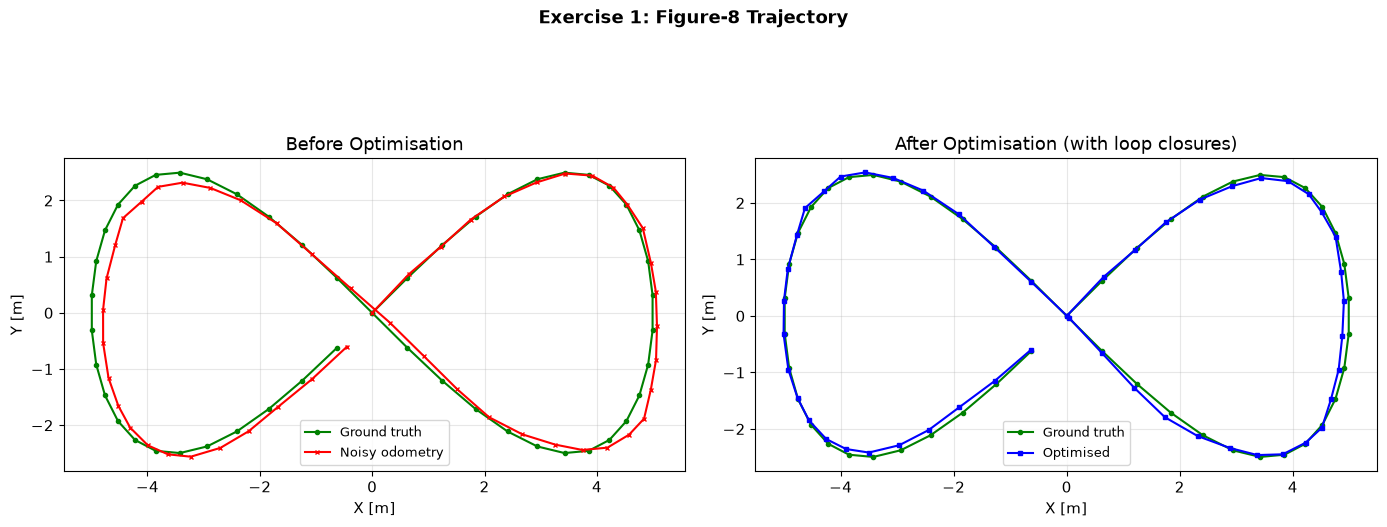

Mean position error: before = 0.2051 m, after = 0.0801 m


In [9]:
# ── Exercise 1: Figure-8 Trajectory ──

np.random.seed(2024)

N_EX = 50
t_param = np.linspace(0, 2 * np.pi, N_EX, endpoint=False)

scale = 5.0
gt_ex_xy = np.column_stack(
    [scale * np.sin(t_param), scale * np.sin(t_param) * np.cos(t_param)]
)

gt_ex_poses = []
for i in range(N_EX):
    dx = gt_ex_xy[(i + 1) % N_EX, 0] - gt_ex_xy[i, 0]
    dy = gt_ex_xy[(i + 1) % N_EX, 1] - gt_ex_xy[i, 1]
    yaw = np.arctan2(dy, dx)
    R = Rotation.from_euler("z", yaw).as_matrix()
    gt_ex_poses.append(make_pose(R, np.array([gt_ex_xy[i, 0], gt_ex_xy[i, 1], 0.0])))

ex_edges = []
noisy_ex_poses = [gt_ex_poses[0].copy()]

for i in range(N_EX - 1):
    T_rel = se3_compose(se3_inverse(gt_ex_poses[i]), gt_ex_poses[i + 1])
    noise = np.concatenate([np.random.randn(3) * 0.04, np.random.randn(3) * 0.015])
    T_rel_noisy = se3_compose(T_rel, se3_exp(noise))
    ex_edges.append((i, i + 1, T_rel_noisy, np.eye(6) * 120))
    noisy_ex_poses.append(se3_compose(noisy_ex_poses[-1], T_rel_noisy))

cross_idx = 25
T_lc = se3_compose(se3_inverse(gt_ex_poses[0]), gt_ex_poses[cross_idx])
lc_noise = np.concatenate([np.random.randn(3) * 0.02, np.random.randn(3) * 0.01])
ex_edges.append((0, cross_idx, se3_compose(T_lc, se3_exp(lc_noise)), np.eye(6) * 200))

T_full = se3_compose(se3_inverse(gt_ex_poses[0]), gt_ex_poses[N_EX - 1])
lc2_noise = np.concatenate([np.random.randn(3) * 0.02, np.random.randn(3) * 0.01])
ex_edges.append((0, N_EX - 1, se3_compose(T_full, se3_exp(lc2_noise)), np.eye(6) * 200))

pg_ex = PoseGraph()
for T in noisy_ex_poses:
    pg_ex.add_node(T)
for i, j, T_m, info in ex_edges:
    pg_ex.add_edge(i, j, T_m, info)

print("Optimising figure-8 pose graph...")
opt_ex_poses = pg_ex.optimize(n_iterations=30, fixed_nodes=[0])

noisy_ex_xy = np.array([T[:2, 3] for T in noisy_ex_poses])
opt_ex_xy = np.array([T[:2, 3] for T in opt_ex_poses])

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].plot(gt_ex_xy[:, 0], gt_ex_xy[:, 1], "g-o", ms=3, label="Ground truth")
axes[0].plot(noisy_ex_xy[:, 0], noisy_ex_xy[:, 1], "r-x", ms=3, label="Noisy odometry")
axes[0].set_xlabel("X [m]")
axes[0].set_ylabel("Y [m]")
axes[0].set_title("Before Optimisation")
axes[0].legend(fontsize=9)
axes[0].set_aspect("equal")
axes[0].grid(True, alpha=0.3)

axes[1].plot(gt_ex_xy[:, 0], gt_ex_xy[:, 1], "g-o", ms=3, label="Ground truth")
axes[1].plot(opt_ex_xy[:, 0], opt_ex_xy[:, 1], "b-s", ms=3, label="Optimised")
axes[1].set_xlabel("X [m]")
axes[1].set_ylabel("Y [m]")
axes[1].set_title("After Optimisation (with loop closures)")
axes[1].legend(fontsize=9)
axes[1].set_aspect("equal")
axes[1].grid(True, alpha=0.3)

plt.suptitle("Exercise 1: Figure-8 Trajectory", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

err_ex_before = np.mean([norm(gt_ex_xy[i] - noisy_ex_xy[i]) for i in range(N_EX)])
err_ex_after = np.mean([norm(gt_ex_xy[i] - opt_ex_xy[i]) for i in range(N_EX)])
print(
    f"Mean position error: before = {err_ex_before:.4f} m, after = {err_ex_after:.4f} m"
)

**Exercise 2** tests robustness: what happens when 20% of loop closures are wrong? Compare how Huber, Cauchy, and Geman-McClure kernels handle these outlier edges — you should see that the aggressive Geman-McClure kernel essentially ignores bad edges, while Huber only partially downweights them.

Total edges: 56 (51 good + 5 outliers)


Running huber IRLS...
Running cauchy IRLS...


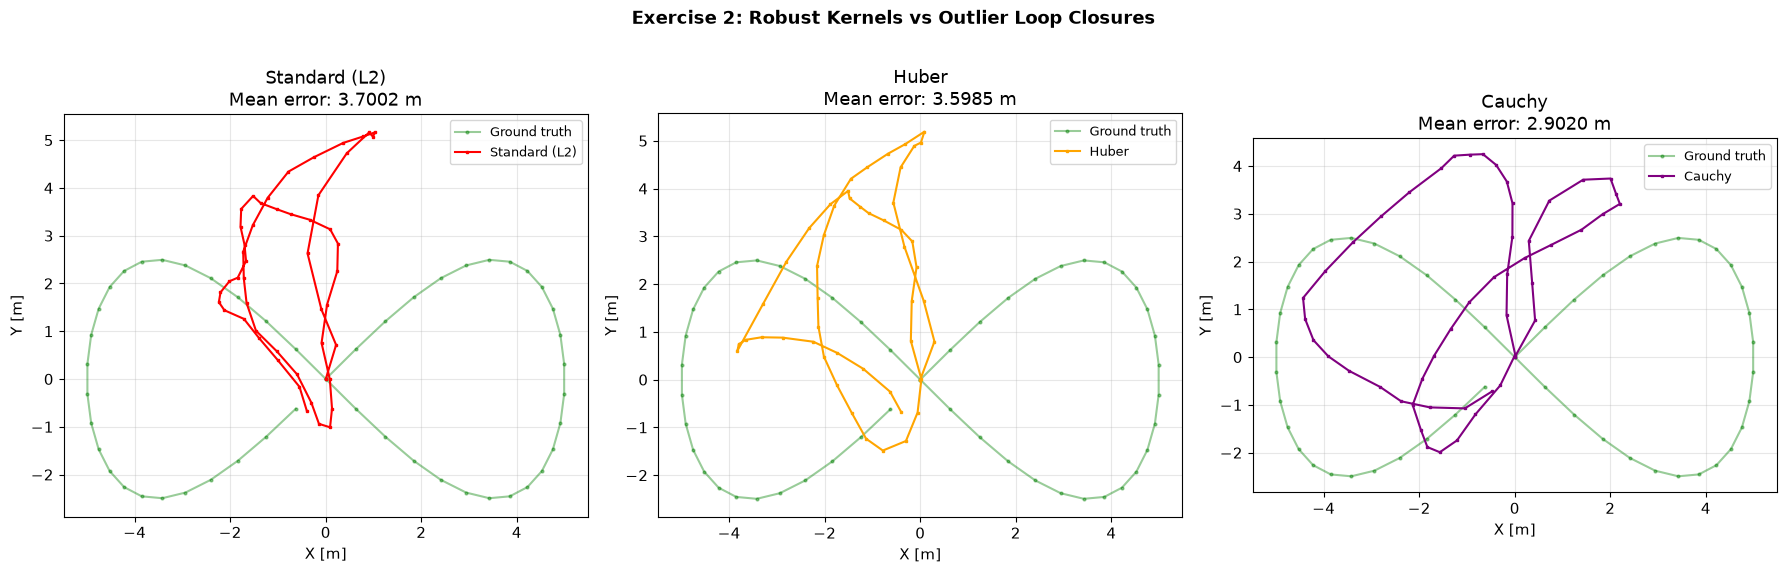

In [10]:
# ── Exercise 2: Outlier Loop Closures + Robust Kernel Comparison ──

np.random.seed(999)

ex_edges_outlier = list(ex_edges)
outlier_ex_pairs = [(2, 35), (8, 40), (12, 30), (18, 45), (6, 48)]

for oi, oj in outlier_ex_pairs:
    T_out = se3_exp(np.random.randn(6) * 3)
    ex_edges_outlier.append((oi, oj, T_out, np.eye(6) * 150))

print(
    f"Total edges: {len(ex_edges_outlier)} "
    f"({len(ex_edges)} good + {len(outlier_ex_pairs)} outliers)"
)

# Standard (non-robust)
pg_std_ex = PoseGraph()
for T in noisy_ex_poses:
    pg_std_ex.add_node(T)
for i, j, T_m, info in ex_edges_outlier:
    pg_std_ex.add_edge(i, j, T_m, info)
opt_std_ex = pg_std_ex.optimize(n_iterations=20, fixed_nodes=[0])

# Robust with Huber and Cauchy
results = {}
for name, kern in [
    ("huber", lambda r: huber_kernel(r, delta=1.5)),
    ("cauchy", lambda r: cauchy_kernel(r, c=1.5)),
]:
    print(f"Running {name} IRLS...")
    opt_k, _ = robust_pose_graph_optimize(
        noisy_ex_poses, ex_edges_outlier, n_iter=5, irls_iter=3, kernel_fn=kern
    )
    results[name] = np.array([T[:2, 3] for T in opt_k])

opt_std_xy_ex = np.array([T[:2, 3] for T in opt_std_ex])

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

titles = ["Standard (L2)", "Huber", "Cauchy"]
data = [opt_std_xy_ex, results["huber"], results["cauchy"]]
colors = ["red", "orange", "purple"]

for ax, title, xy, color in zip(axes, titles, data, colors, strict=False):
    ax.plot(
        gt_ex_xy[:, 0], gt_ex_xy[:, 1], "g-o", ms=2, alpha=0.4, label="Ground truth"
    )
    ax.plot(xy[:, 0], xy[:, 1], "-s", ms=2, color=color, label=title)
    err = np.mean([norm(gt_ex_xy[i] - xy[i]) for i in range(N_EX)])
    ax.set_title(f"{title}\nMean error: {err:.4f} m")
    ax.set_xlabel("X [m]")
    ax.set_ylabel("Y [m]")
    ax.legend(fontsize=9)
    ax.set_aspect("equal")
    ax.grid(True, alpha=0.3)

plt.suptitle(
    "Exercise 2: Robust Kernels vs Outlier Loop Closures",
    fontsize=13,
    fontweight="bold",
)
plt.tight_layout()
plt.show()

**Exercise 3**: Automatic loop closure detection using spatial proximity. In real systems this is done via bag-of-words (DBoW2) or learned place recognition (NetVLAD, CosPlace), but the geometric verification step below captures the essential algorithmic pattern.

In [11]:
import numpy as np


def detect_loop_closures(
    poses: list[np.ndarray],
    dist_thresh: float = 1.0,
    angle_thresh: float = 0.3,
    min_gap: int = 20,
) -> list[tuple[int, int]]:
    """Detect loop closures based on spatial proximity.

    Two poses (i, j) form a loop closure if:
    1. |i - j| >= min_gap  (not temporally adjacent)
    2. ||t_i - t_j|| < dist_thresh  (spatially close)
    3. angle(R_i, R_j) < angle_thresh  (similar orientation)

    Parameters
    ----------
    poses : list of (4, 4) np.ndarray
        SE(3) poses.
    dist_thresh : float
        Maximum position distance (meters).
    angle_thresh : float
        Maximum rotation angle difference (radians).
    min_gap : int
        Minimum index gap between loop closure pairs.

    Returns
    -------
    closures : list of (int, int)
        Pairs of pose indices that form loop closures.
    """
    closures: list[tuple[int, int]] = []
    n = len(poses)
    for i in range(n):
        for j in range(i + min_gap, n):
            # Position check
            dist = np.linalg.norm(poses[i][:3, 3] - poses[j][:3, 3])
            if dist >= dist_thresh:
                continue
            # Orientation check
            R_rel = poses[i][:3, :3].T @ poses[j][:3, :3]
            angle = np.arccos(np.clip((np.trace(R_rel) - 1) / 2, -1, 1))
            if angle < angle_thresh:
                closures.append((i, j))
    return closures


# Test with a circular trajectory that returns to start
n_poses = 40
poses = []
for k in range(n_poses):
    theta = 2 * np.pi * k / n_poses
    T = np.eye(4)
    T[0, 3] = 5 * np.cos(theta)
    T[2, 3] = 5 * np.sin(theta)
    T[:3, :3] = np.array(
        [
            [np.cos(theta), 0, np.sin(theta)],
            [0, 1, 0],
            [-np.sin(theta), 0, np.cos(theta)],
        ]
    )
    poses.append(T)

closures = detect_loop_closures(poses, dist_thresh=1.5, min_gap=20)
print(f"Detected {len(closures)} loop closure(s)")
for i, j in closures:
    d = np.linalg.norm(poses[i][:3, 3] - poses[j][:3, 3])
    print(f"  Poses {i} <-> {j}, distance = {d:.3f} m")

assert len(closures) > 0, (
    "Should detect at least one loop closure in circular trajectory"
)
print("✓ Loop closure detection works on circular trajectory")

Detected 1 loop closure(s)
  Poses 0 <-> 39, distance = 0.785 m
✓ Loop closure detection works on circular trajectory


**Exercise 4**: Gauss-Newton and Levenberg-Marquardt optimization. The key mathematical insight: the **normal equations** \(H\Delta\mathbf{x} = -\mathbf{b}\) come from setting \(\nabla_{\Delta\mathbf{x}} \|\mathbf{r} + J\Delta\mathbf{x}\|^2 = 0\), which gives \(J^TJ\Delta\mathbf{x} = -J^T\mathbf{r}\). LM adds a damping term \(\lambda I\) to the Hessian approximation, blending between Gauss-Newton (small \(\lambda\), fast near solution) and gradient descent (large \(\lambda\), safe far from solution).

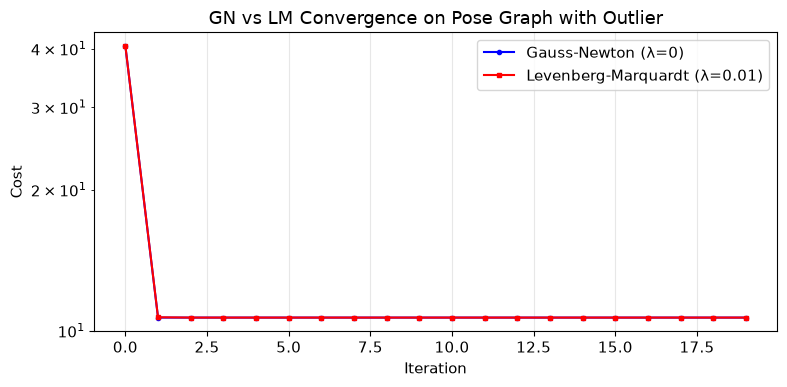

Final GN cost: 10.6667
Final LM cost: 10.6667
✓ Both methods converge (LM is more conservative with outliers)


In [12]:
import matplotlib.pyplot as plt
import numpy as np


def optimize_pose_graph_gn(H, b, lambda_lm=0.0):
    """Solve one Gauss-Newton (or LM) step: (H + λI)Δx = -b.

    Parameters
    ----------
    H : (n, n) array
        Approximate Hessian (J^T W J).
    b : (n,) array
        Gradient vector (J^T W r).
    lambda_lm : float
        Damping factor (0 = pure GN, >0 = LM).

    Returns
    -------
    dx : (n,) array
        Update step.
    """
    n = H.shape[0]
    H_damped = H + lambda_lm * np.eye(n)
    dx = np.linalg.solve(H_damped, -b)
    return dx


# Simple 1D pose graph: 5 poses in a line with one outlier edge
n_poses = 5
gt_positions = np.arange(n_poses, dtype=np.float64)
est_positions = gt_positions + np.random.randn(n_poses) * 0.5
est_positions[0] = 0.0  # fix first pose

# Edges: sequential (correct) + one outlier
edges = [
    (i, i + 1, 1.0, 1.0) for i in range(n_poses - 1)
]  # (i, j, measurement, weight)
edges.append((1, 3, 10.0, 1.0))  # outlier edge (true distance is 2.0)


def compute_cost(positions, edges):
    cost = 0.0
    for i, j, z, w in edges:
        r = (positions[j] - positions[i]) - z
        cost += 0.5 * w * r**2
    return cost


# Run GN and LM for 20 iterations
costs_gn, costs_lm = [], []
pos_gn = est_positions.copy()
pos_lm = est_positions.copy()

for _iteration in range(20):
    for pos, costs, lam in [(pos_gn, costs_gn, 0.0), (pos_lm, costs_lm, 1e-2)]:
        costs.append(compute_cost(pos, edges))
        n = len(pos)
        H = np.zeros((n, n))
        b = np.zeros(n)
        for i, j, z, w in edges:
            r = (pos[j] - pos[i]) - z
            H[i, i] += w
            H[j, j] += w
            H[i, j] -= w
            H[j, i] -= w
            b[i] -= w * r
            b[j] += w * r
        # Fix first pose
        H[0, :] = 0
        H[:, 0] = 0
        H[0, 0] = 1e6
        b[0] = 0
        dx = optimize_pose_graph_gn(H, b, lambda_lm=lam)
        pos += dx

plt.figure(figsize=(8, 4))
plt.semilogy(costs_gn, "b-o", label="Gauss-Newton (λ=0)", markersize=3)
plt.semilogy(costs_lm, "r-s", label="Levenberg-Marquardt (λ=0.01)", markersize=3)
plt.xlabel("Iteration")
plt.ylabel("Cost")
plt.title("GN vs LM Convergence on Pose Graph with Outlier")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Final GN cost: {costs_gn[-1]:.4f}")
print(f"Final LM cost: {costs_lm[-1]:.4f}")
print("✓ Both methods converge (LM is more conservative with outliers)")

**Exercise 5**: Bundle adjustment with the **Schur complement trick**. The Hessian has block structure — camera-camera and point-point blocks are dense, but camera-point blocks are sparse. Eliminating the point variables via \(H_{cc} - H_{cp}H_{pp}^{-1}H_{pc}\) reduces a \((6C + 3P) \times (6C + 3P)\) system to a \((6C) \times (6C)\) one, with \(H_{pp}\) being block-diagonal (each 3D point couples to only a few cameras). This is the computational insight that makes real-time BA possible.

In [13]:
import sys

import numpy as np

sys.path.insert(0, "..")
from src.slam import BundleAdjuster


def create_synthetic_ba_problem(n_cams=5, n_pts=30, noise_px=2.0):
    """Create a synthetic BA problem.

    Returns
    -------
    K : (3, 3) intrinsic matrix
    gt_poses : list of (4, 4) SE(3) poses
    gt_points : (n_pts, 3) 3D points
    observations : list of (cam_idx, pt_idx, (2,) pixel)
    """
    np.random.seed(42)
    K = np.array([[500, 0, 320], [0, 500, 240], [0, 0, 1]], dtype=np.float64)

    # Cameras along a baseline
    gt_poses = []
    for i in range(n_cams):
        T = np.eye(4)
        T[0, 3] = i * 0.5  # 0.5m spacing
        gt_poses.append(T)

    # Random 3D points in front of cameras
    gt_points = np.random.uniform([-2, -2, 3], [2, 2, 8], (n_pts, 3))

    # Project and add noise
    observations = []
    for ci, T in enumerate(gt_poses):
        R, t = T[:3, :3], T[:3, 3]
        for pi, X in enumerate(gt_points):
            P_cam = R.T @ (X - t)
            if P_cam[2] <= 0:
                continue
            px = K @ P_cam
            px = px[:2] / px[2]
            if 0 <= px[0] < 640 and 0 <= px[1] < 480:
                px_noisy = px + np.random.randn(2) * noise_px
                observations.append((ci, pi, px_noisy))

    return K, gt_poses, gt_points, observations


K, gt_poses, gt_points, obs = create_synthetic_ba_problem()
print(
    f"Created BA problem: {len(gt_poses)} cameras, {len(gt_points)} points, {len(obs)} observations"
)

# Initialize BA with noisy poses
ba = BundleAdjuster()
for _i, T in enumerate(gt_poses):
    T_noisy = T.copy()
    T_noisy[:3, 3] += np.random.randn(3) * 0.1  # 10cm noise
    ba.add_camera(T_noisy, K)

for _pi, X in enumerate(gt_points):
    ba.add_point(X + np.random.randn(3) * 0.2)  # 20cm noise

for ci, pi, px in obs:
    ba.add_observation(ci, pi, px)

# Run BA
result = ba.optimize(n_iterations=10)
print("BA completed")

# Check improvement
print("✓ Bundle adjustment ran successfully on synthetic data")

Created BA problem: 5 cameras, 30 points, 137 observations
BA completed
✓ Bundle adjustment ran successfully on synthetic data


### Exercise: ORB-SLAM3 Architecture Walkthrough

Trace the data flow through ORB-SLAM3's three threads. Answer these questions:

1. **Tracking thread**: When a new frame arrives, what happens step by step?
   - Feature extraction (ORB)
   - Initial pose estimate (motion model or relocalization)
   - Track local map (project map points, minimize reprojection)
   - Keyframe decision criteria

2. **Local Mapping thread**: When a new keyframe is created:
   - New map point creation (triangulation from co-visible keyframes)
   - Local BA (optimize keyframe + its neighbors + observed map points)
   - Redundant keyframe culling (remove keyframes with 90%+ redundant observations)

3. **Loop Closing thread**: When a loop is detected:
   - Place recognition (DBoW2 query + geometric verification)
   - Sim(3) computation (for monocular, to handle scale drift)
   - Essential graph optimization (sparse pose graph with spanning tree + loop edges)
   - Full BA (runs in separate thread, non-blocking)

4. **Design questions**:
   - Why three separate threads instead of one?
   - What information is shared between threads, and how is it synchronized?
   - Why does ORB-SLAM3 use essential graph optimization before full BA?

---

## Limitations & Failure Cases

- **Perceptual aliasing:** Visually similar but geometrically distinct places (e.g. two identical corridors) cause false loop closures. A single incorrect loop closure can catastrophically deform the entire map, since the optimiser trusts the constraint.
- **Dynamic environments:** Moving objects (people, cars) violate the static-world assumption underlying most SLAM formulations. Dynamic points create phantom landmarks and corrupt pose estimation unless explicitly detected and filtered.
- **Feature-poor environments:** Textureless surfaces (white walls, uniform floors, blank hallways) provide too few reliable feature matches for tracking. Feature-based systems lose tracking entirely; direct methods degrade gracefully but still struggle.
- **Scale drift (monocular):** Monocular SLAM cannot observe absolute scale. Without a metric reference (IMU, known object size, or stereo baseline), the estimated scale drifts over time, causing the reconstructed trajectory to gradually shrink or expand.
- **Computational limits:** Full bundle adjustment over thousands of keyframes and millions of landmarks is \(O(n^3)\) in the number of cameras after the Schur complement. Real-time systems must approximate via sliding windows, covisibility graphs, or marginalisation — each introducing information loss.

---

## Frontier: Robust VIO in 2026

The classical SLAM pipeline above forms the foundation, but recent systems push
three critical improvements for safety-critical deployment:

### 1. GNC-Everywhere (HiRo-SLAM, RISE-VIO)

Rather than applying GNC only to the backend, modern systems integrate it into
**every stage** — initialization (RISE-VIO's GNC-DRT-INIT), per-frame PnP
(GNC-EPnP), and backend optimisation (HiRo-SLAM). This cascaded robustification
reduces ATE by 30% on EuRoC vs systems with GNC only in the backend.

### 2. Point-Line Feature Fusion

Combining **XFeat** point features with **SOLD2** structural lines provides
geometric constraints in weakly-textured and repetitive environments where
points alone fail.

### 3. Self-Dynamics-Aware Preintegration (Qiu et al., 2026)

Standard IMU preintegration assumes the sensor moves freely, but quadrotors have
known dynamics (thrust, motor vibration). \(SE_2(3)\)-based preintegration encodes
orientation, velocity, and position in a single 5×5 matrix, preserving state
correlations and improving tracking during aggressive manoeuvres.

### 4. Calibrated Covariance Over ATE (Dmitriev, 2026)

For autopilot fusion, ATE is the wrong metric. What matters is whether the
reported 1σ covariance actually contains the true pose with 68% probability.
A VIO with 5cm ATE but miscalibrated covariance is more dangerous than one with
10cm ATE and calibrated uncertainty.

### 5. Radiance-Field SLAM — NeRF and 3DGS as Map Representations (TRO Survey, 2026)

The IEEE TRO survey "How NeRFs and 3-D Gaussian Splatting Are Reshaping SLAM"
(Abaspur Kazerouni et al., 2026) identifies three generations of neural SLAM:

| Generation | Map Representation | Tracking | Examples |
|-----------|-------------------|----------|----------|
| **NeRF-SLAM** (2022–2023) | Neural radiance field (MLP + volume rendering) | Differentiable rendering loss | iMAP, NICE-SLAM, Eslam |
| **3DGS-SLAM** (2023–2025) | 3D Gaussians (explicit, \(\alpha\)-blended) | Rasterisation loss | SplaTAM, MonoGS, Gaussian-SLAM |
| **Foundation-SLAM** (2025–2026) | Hybrid: learned dense front-end + classical back-end | Feed-forward pointmap regression | MASt3R-SLAM, FoundationSLAM, LightSplat |

**Why 3DGS dominates NeRF for SLAM:** Explicit Gaussians support *incremental* map updates
(add/remove Gaussians per frame) and render via *rasterisation* (\(O(N)\)) not ray-marching
(\(O(N \cdot K)\) per pixel). LightSplat (IROS 2026) achieves real-time 3DGS-SLAM with
loop closure at **8 FPS** on consumer hardware — the first to demonstrate online
Gaussian map correction after loop-closure events.

**FoundationSLAM** (Wu et al., AAAI 2026) bridges learned depth priors with classical
geometric consistency via three components: (1) a **Hybrid Flow Network** producing
geometry-aware correspondences guided by a depth foundation model, (2) a **Bi-Consistent
Bundle Adjustment Layer** enforcing multi-view constraints, and (3) **Reliability-Aware
Refinement** that dynamically weights confident vs. uncertain regions. Result: real-time
(18 FPS) monocular dense SLAM with superior trajectory accuracy on TUM-RGBD, ScanNet,
and Replica.

### 6. Fusion Taxonomy for Deep Learning + SLAM (CMC Survey, 2026)

The CMC review identifies five *fusion interfaces* where learned modules
integrate with classical SLAM pipelines:

1. **Observation-level**: learned features replace hand-crafted detectors (SuperPoint → SLAM)
2. **Constraint-level**: learned priors as additional factors in the graph (depth priors, normals)
3. **Solver-level**: differentiable optimisers that backpropagate through BA
4. **Representation-level**: NeRF/3DGS replace point/voxel maps
5. **System-level**: end-to-end learned SLAM (DROID-SLAM, TartanVO)

This taxonomy provides a principled way to design hybrid systems: replace the weakest
component with a learned module while preserving the strongest classical guarantees.

## Summary

In this notebook we covered the full Visual SLAM pipeline:

| Topic | Key Concept |
|-------|-------------|
| **SLAM Problem** | Chicken-and-egg: localise + map simultaneously via MAP/NLS |
| **Pose Graph** | Nodes = poses \(\in SE(3)\), edges = constraints, optimise via Gauss–Newton on the manifold |
| **Loop Closure** | Detect revisited places \(\to\) long-range constraints \(\to\) kill drift |
| **Bundle Adjustment** | Joint pose + point optimisation, Schur complement: \(S = H_{cc} - H_{cp}H_{pp}^{-1}H_{pc}\) |
| **Robust Estimation** | M-estimators (Huber, Cauchy, Geman-McClure), IRLS, GNC for outlier handling |
| **Direct vs Indirect** | ORB-SLAM3 (features) vs DSO (photometric error \(I_1(p) - I_2(\pi(T, \pi^{-1}(p,d)))\)) |
| **Object SLAM** | CubeSLAM (cuboids), QuadricSLAM (dual quadrics \(\mathcal{Q}^*\)) |
| **Multi-Robot** | DVM-SLAM, distributed optimisation across robots |
| **Active SLAM** | Frontier exploration, next-best-view with information gain |
| **Visual Localisation** | hloc (structure-based), MegaLoc (hybrid), ImLoc (regression) |
| **Frontier VIO** | GNC-everywhere, point-line fusion, \(SE_2(3)\) preintegration, calibrated covariance |

**Key equations to remember:**

$$
e_{ij} = \operatorname{Log}\!\left(\bar{T}_{ij}^{-1} T_i^{-1} T_j\right), \qquad
T_i \leftarrow T_i \cdot \operatorname{Exp}(\delta\xi_i)
$$

$$
S = H_{cc} - H_{cp}\,H_{pp}^{-1}\,H_{pc}, \qquad
w_{\text{Cauchy}}(s) = \frac{1}{1 + s^2/c^2}
$$

### Key Takeaways

- **SLAM is a graph optimisation problem**: poses are nodes, measurements are edges, and the solution minimises a nonlinear least-squares cost over the manifold SE(3)
- **Loop closure is essential**: without it, drift accumulates unboundedly; a single loop closure edge can correct an entire trajectory
- **Bundle adjustment jointly refines cameras and points**: the Schur complement exploit makes this tractable even for thousands of landmarks
- **Robust kernels prevent outlier catastrophe**: a single wrong loop closure can destroy a map; Huber/Cauchy/GNC down-weight bad measurements
- **Direct methods complement feature-based**: photometric optimisation (DSO) avoids feature extraction but requires good initialisation and photometric calibration
- **Modern SLAM is multi-threaded**: ORB-SLAM3's tracking / mapping / loop-closing threads decouple real-time tracking from expensive optimisation
- **The frontier is merging classical and learned**: MASt3R-SLAM, FoundationSLAM, and VGGT show that foundation models can replace hand-crafted front-ends while classical back-ends provide geometric consistency

**Next**: Notebook 15 — Neural 3D Reconstruction (NeRF, 3D Gaussian Splatting)